In [188]:
import warnings
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import numpy as np
from scipy import stats
import pandas as pd

df1 = pd.read_csv('laptops_cleaned.csv')
df2 = pd.read_csv('smartphones_cleaned.csv')
df3 = pd.read_csv('tablets_cleaned.csv')

print(df1.shape, df2.shape, df3.shape)
warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 120

(5376, 41) (5382, 48) (5553, 53)


In [229]:
num1 = ["price","price_old","rating_card","reviews_card","rating_seller",
        "ram","ssd_capacity","screen_diagonal","ghz_processor","processor_cores",
        "hz_screen","battery_capacity","weight_kg","discount_pct"]

num2 = ["price","price_old","rating_card","reviews_card","rating_seller",
        "ram","built-in_memory","screen_diagonal","main_camera","front_camera",
        "battery_capacity","weight_g","hz_screen","discount_pct","total_camera_mp"]

num3 = ["price","price_old","rating_card","reviews_card","rating_seller",
        "ram","internal_storage","screen_diagonal","main_camera",
        "battery_capacity","weight_g","hz_screen","ppi","ghz_processor"]

def desc_stats(df, num_cols, label):
    d = df[num_cols].describe(percentiles=[.25,.5,.75]).T
    d["mode"]  = [df[c].mode()[0] if df[c].notna().any() else np.nan for c in num_cols]
    d["skew"]  = [df[c].skew() for c in num_cols]
    d["kurt"]  = [df[c].kurt() for c in num_cols]
    print(f"{'='*60}")
    print(f"  {label}")
    print(f"{'='*60}")
    return d[["count","mean","std","min","25%","50%","75%","max","mode","skew","kurt"]].round(2)

display(desc_stats(df1, num1, "LAPTOPS"))

  LAPTOPS


,count,mean,std,min,25%,50%,75%,max,mode,skew,kurt
price,5376.0,487430.24,346981.04,3706.00,424220.00,424220.00,424220.00,4920407.00,424220.00,4.65,35.57
price_old,5376.0,1088760.67,1221649.70,7483.00,834731.00,834731.00,834731.00,15482196.00,834731.00,6.62,59.24
rating_card,5376.0,4.86,0.27,1.00,4.90,4.90,4.90,5.00,4.90,-8.29,91.86
reviews_card,5376.0,103.31,336.01,1.00,30.00,30.00,30.00,4706.00,30.00,7.63,73.88
rating_seller,5376.0,4.81,0.14,1.00,4.80,4.80,4.90,5.00,4.80,-9.22,216.04
ram,5376.0,19.57,42.78,0.12,16.00,16.00,16.00,1024.00,16.00,20.72,466.22
ssd_capacity,5376.0,681.72,427.58,30.00,512.00,512.00,1024.00,4096.00,512.00,2.48,11.73
screen_diagonal,5376.0,15.38,1.23,7.00,14.60,15.60,16.00,18.50,15.60,-1.04,4.03
ghz_processor,5376.0,2.84,1.08,0.10,2.10,2.60,3.50,6.00,2.60,0.57,-0.30
processor_cores,5376.0,8.09,4.41,1.00,4.00,8.00,10.00,32.00,8.00,1.38,2.73


In [190]:
display(desc_stats(df2, num2, "SMARTPHONES"))

  SMARTPHONES


,count,mean,std,min,25%,50%,75%,max,mode,skew,kurt
price,5382.0,105863.24,142614.46,619.00,52289.00,61762.00,87470.00,1446336.00,61762.00,4.59,24.99
price_old,5382.0,386373.18,500405.93,1316.00,214569.00,322025.00,376700.25,8355213.00,322025.00,8.16,84.77
rating_card,5382.0,4.70,0.39,1.00,4.60,4.80,4.90,5.00,4.90,-3.24,17.62
reviews_card,5382.0,433.60,1706.09,1.00,26.00,63.00,180.00,26607.00,63.00,8.90,103.68
rating_seller,5382.0,4.68,0.28,3.30,4.50,4.80,4.90,5.00,4.90,-1.51,2.28
ram,5382.0,10.36,4.27,1.00,8.00,12.00,12.00,24.00,12.00,0.30,-0.18
built-in_memory,5382.0,475.29,408.65,2.00,256.00,256.00,512.00,2048.00,256.00,1.72,3.47
screen_diagonal,5382.0,6.70,0.61,1.77,6.60,6.78,6.83,10.00,6.80,-2.49,19.53
main_camera,5382.0,74.67,54.40,0.30,48.00,50.00,108.00,200.00,50.00,1.08,0.43
front_camera,5382.0,26.98,20.47,0.08,12.00,16.00,50.00,65.00,8.00,0.70,-1.04


In [191]:
display(desc_stats(df3, num3, "TABLETS"))

  TABLETS


,count,mean,std,min,25%,50%,75%,max,mode,skew,kurt
price,5553.0,107526.78,174834.63,1413.00,54883.0,60747.50,73733.0,1728329.0,60747.5,5.22,32.47
price_old,5553.0,419168.25,664324.47,2424.00,224429.0,302265.00,337184.0,11536202.0,302265.0,6.68,58.92
rating_card,5553.0,4.78,0.43,1.00,4.8,4.90,4.9,5.0,4.9,-4.97,32.77
reviews_card,5553.0,120.09,427.93,1.00,22.0,33.00,53.0,5355.0,33.0,8.02,75.88
rating_seller,5553.0,4.75,0.20,1.00,4.7,4.80,4.9,5.0,4.8,-2.88,25.23
ram,5553.0,73.48,237.02,0.12,8.0,12.00,16.0,1024.0,12.0,3.68,11.73
internal_storage,5553.0,455.61,434.52,1.00,128.0,256.00,1024.0,2048.0,1024.0,1.00,0.41
screen_diagonal,5553.0,10.50,1.63,5.50,10.1,10.36,11.0,32.0,10.1,1.70,22.25
main_camera,5553.0,20.60,15.69,0.30,12.0,13.00,32.0,108.0,13.0,2.11,6.81
battery_capacity,5553.0,9057.54,3111.59,2000.00,7606.0,9705.00,10000.0,33280.0,10000.0,2.49,16.54


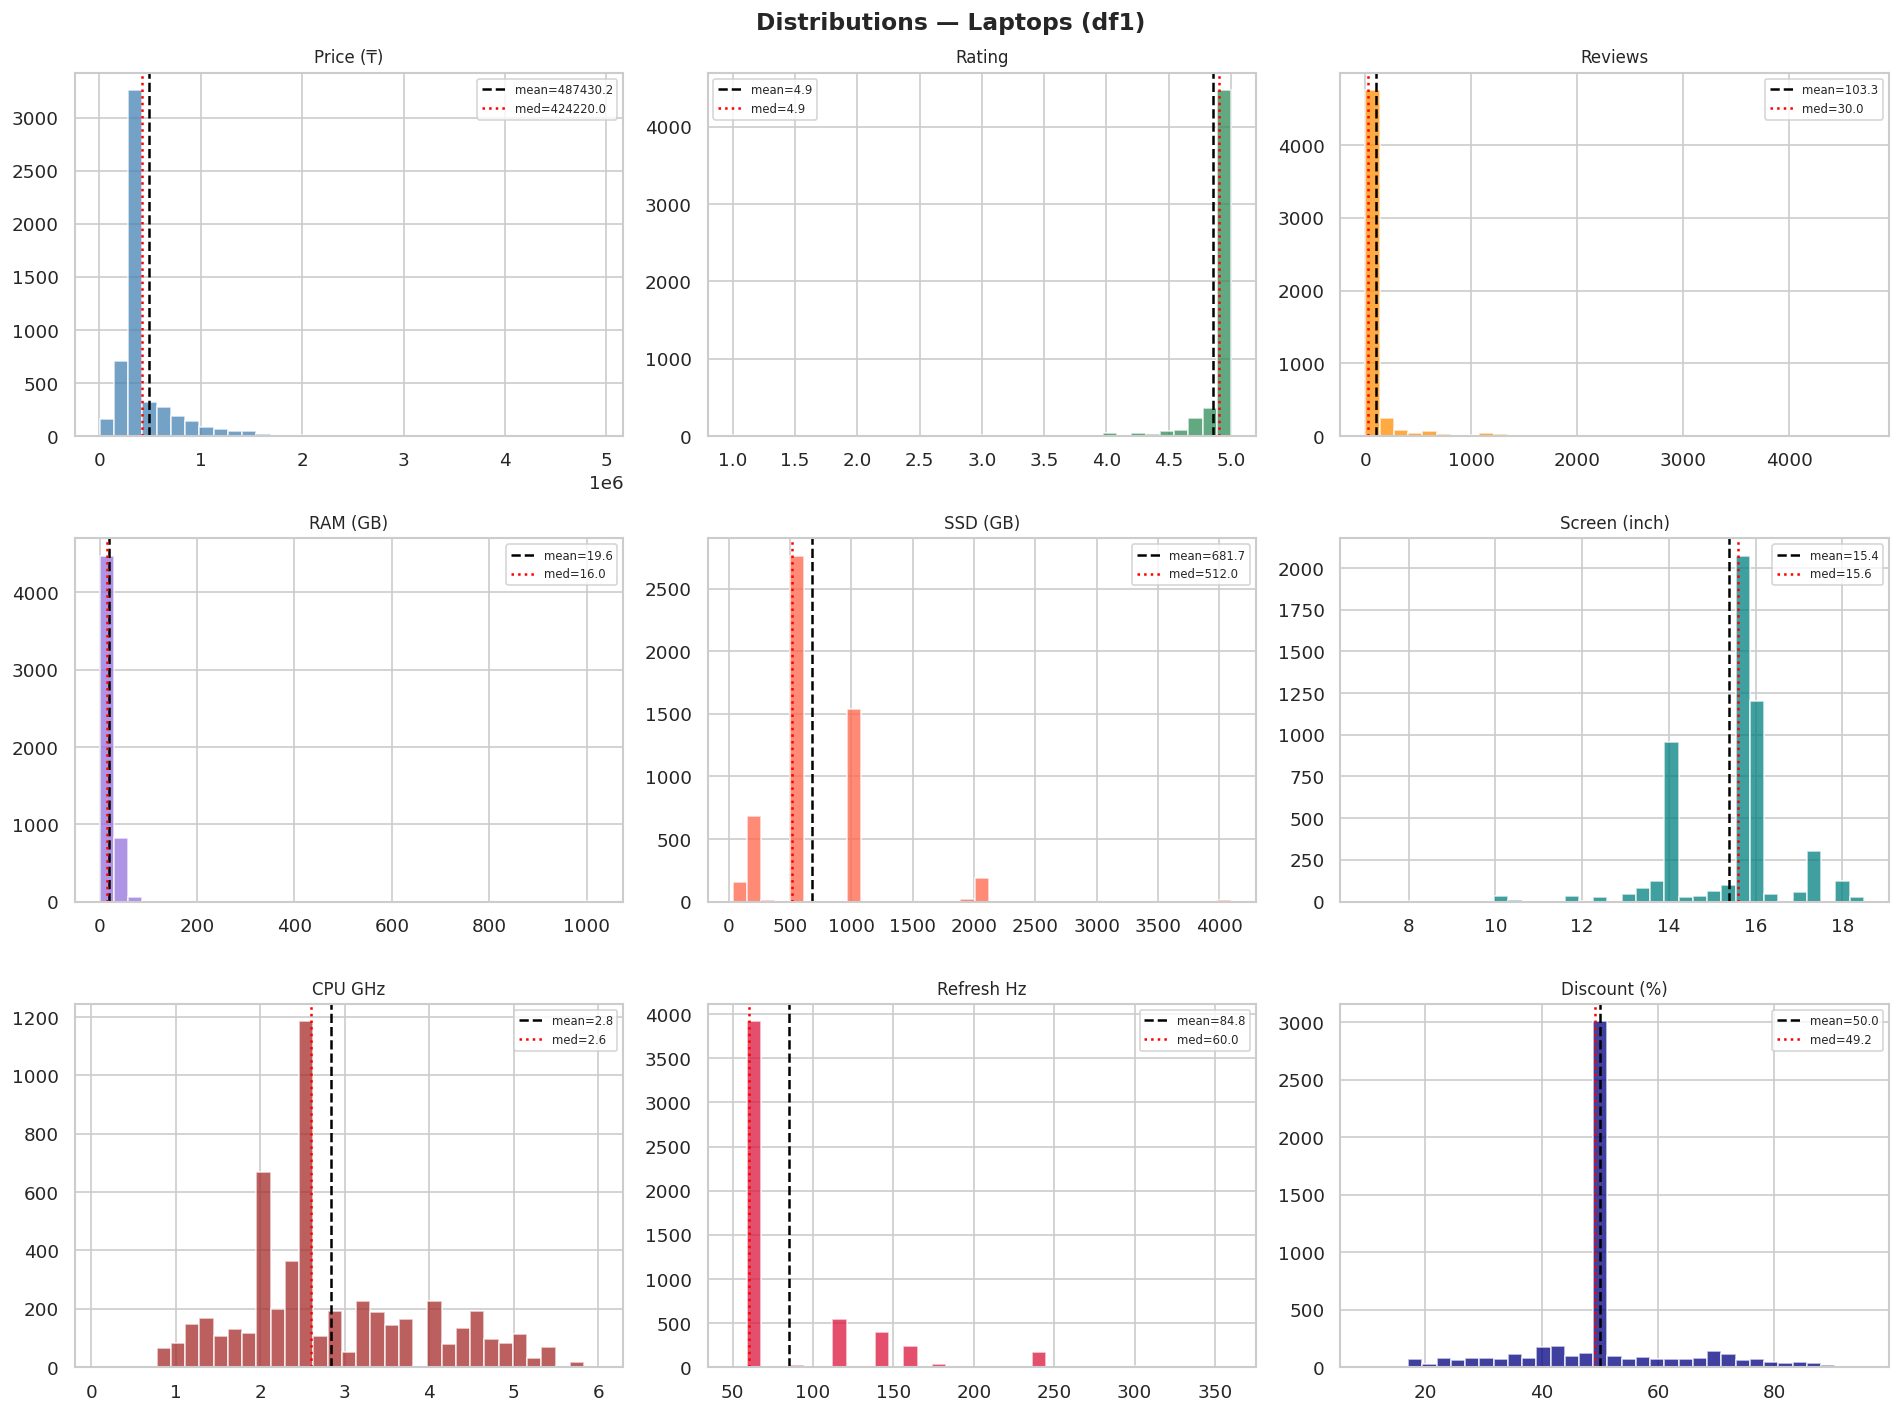

In [230]:
fig, axes = plt.subplots(3, 3, figsize=(16, 12))
fig.suptitle("Distributions — Laptops (df1)", fontsize=14, fontweight="bold")

plot_cols1 = [
    ("price",        "Price (₸)",          "steelblue"),
    ("rating_card",  "Rating",             "seagreen"),
    ("reviews_card", "Reviews",            "darkorange"),
    ("ram",          "RAM (GB)",           "mediumpurple"),
    ("ssd_capacity", "SSD (GB)",           "tomato"),
    ("screen_diagonal","Screen (inch)",    "teal"),
    ("ghz_processor","CPU GHz",           "brown"),
    ("hz_screen",    "Refresh Hz",         "crimson"),
    ("discount_pct", "Discount (%)",       "navy"),
]
for ax, (col, label, color) in zip(axes.flatten(), plot_cols1):
    data = df1[col].dropna()
    ax.hist(data, bins=35, color=color, alpha=0.75, edgecolor="white")
    ax.axvline(data.mean(),   color="black", lw=1.5, ls="--", label=f"mean={data.mean():.1f}")
    ax.axvline(data.median(), color="red",   lw=1.5, ls=":",  label=f"med={data.median():.1f}")
    ax.set_title(label, fontsize=10)
    ax.legend(fontsize=7)
plt.tight_layout(); plt.show()

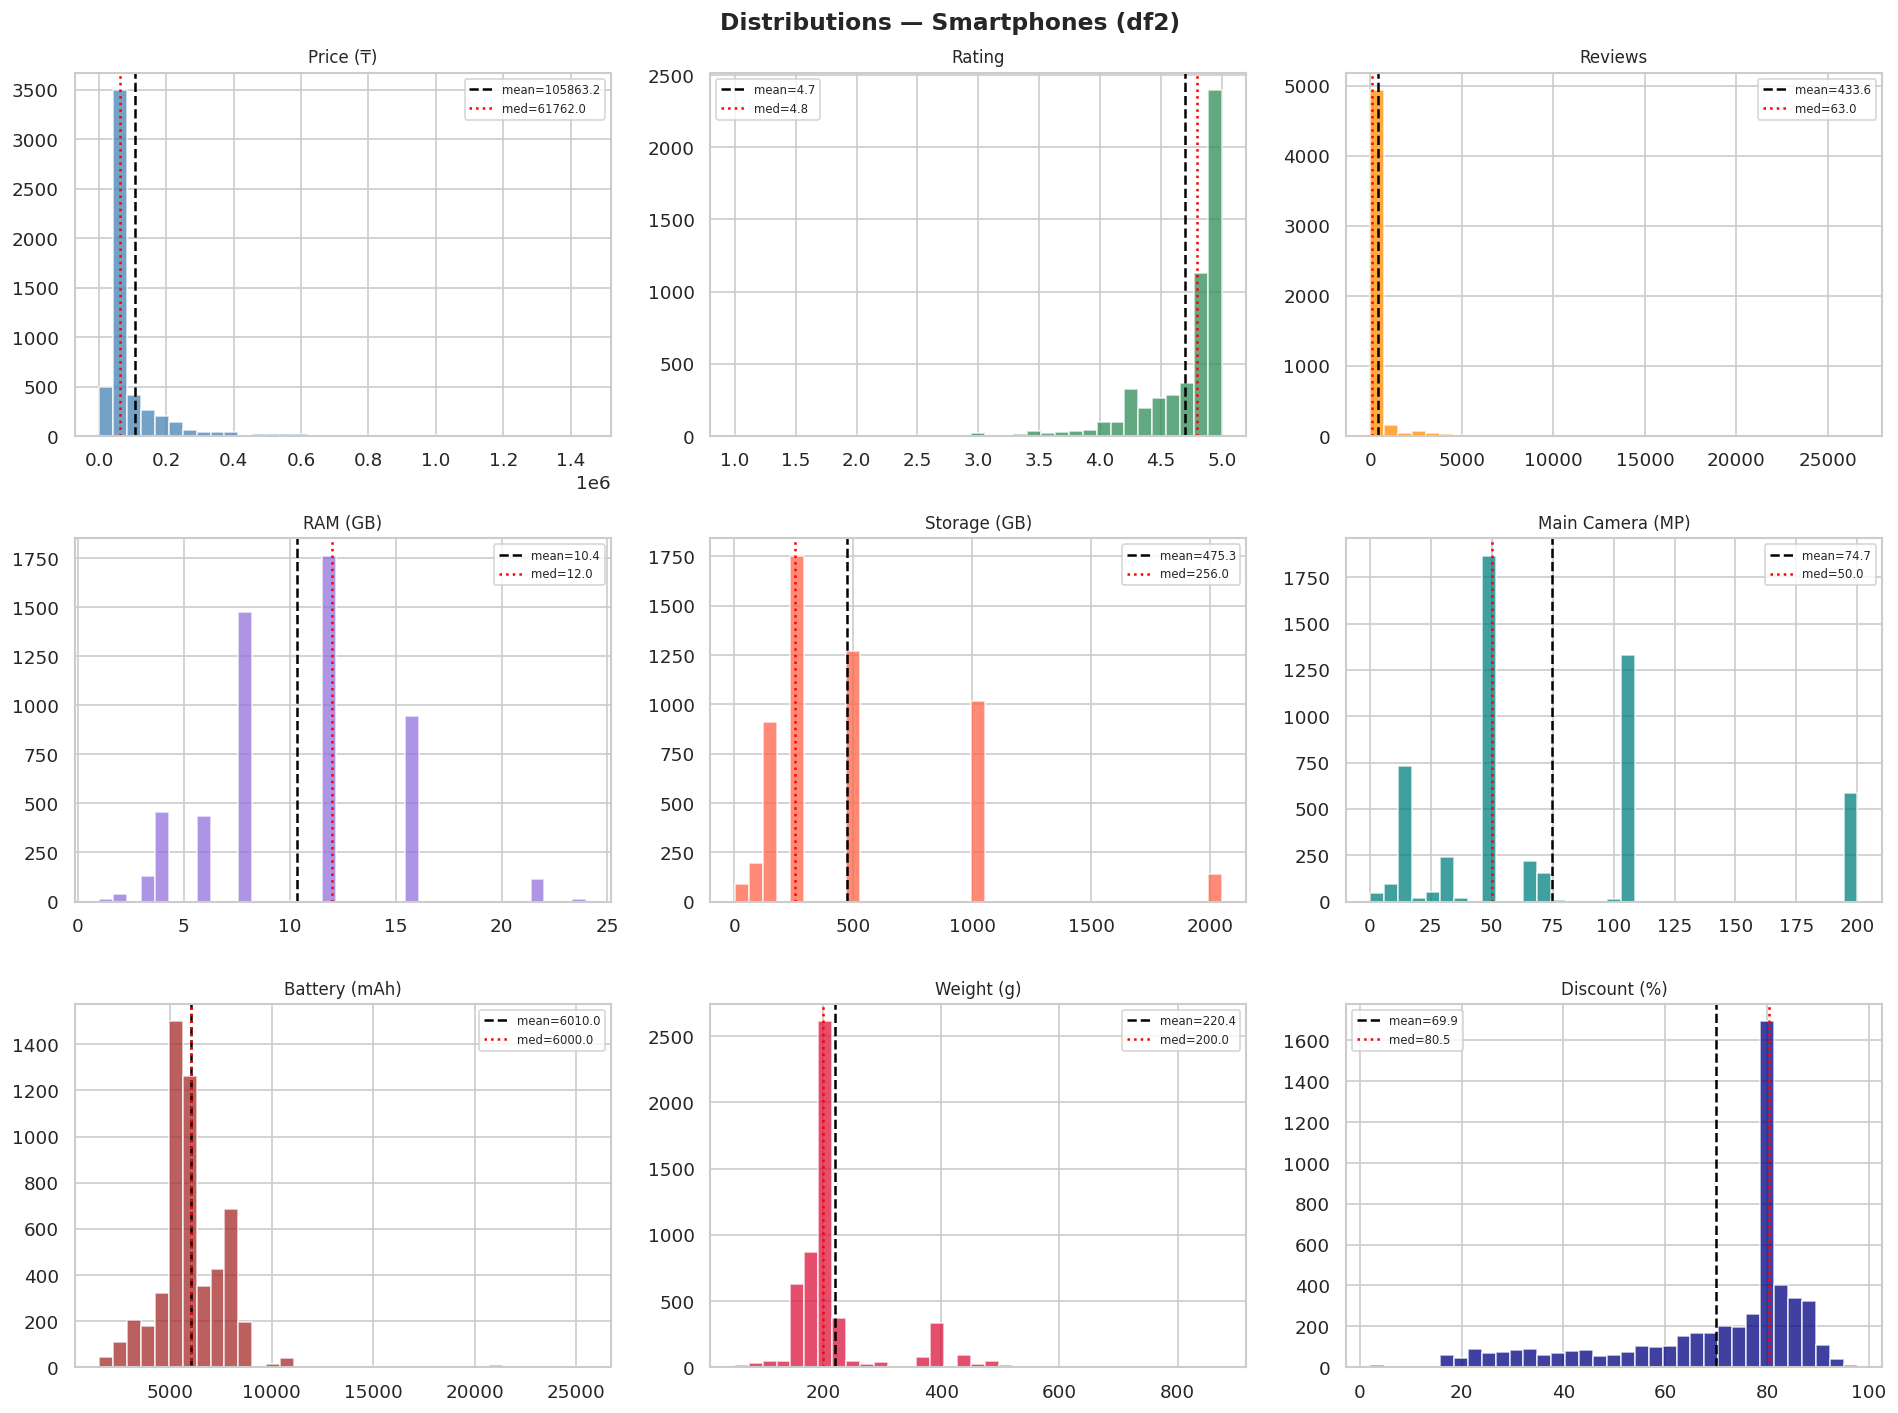

In [193]:
fig, axes = plt.subplots(3, 3, figsize=(16, 12))
fig.suptitle("Distributions — Smartphones (df2)", fontsize=14, fontweight="bold")

plot_cols2 = [
    ("price",        "Price (₸)",          "steelblue"),
    ("rating_card",  "Rating",             "seagreen"),
    ("reviews_card", "Reviews",            "darkorange"),
    ("ram",          "RAM (GB)",           "mediumpurple"),
    ("built-in_memory","Storage (GB)",    "tomato"),
    ("main_camera",  "Main Camera (MP)",   "teal"),
    ("battery_capacity","Battery (mAh)",  "brown"),
    ("weight_g",     "Weight (g)",         "crimson"),
    ("discount_pct", "Discount (%)",       "navy"),
]
for ax, (col, label, color) in zip(axes.flatten(), plot_cols2):
    data = df2[col].dropna()
    ax.hist(data, bins=35, color=color, alpha=0.75, edgecolor="white")
    ax.axvline(data.mean(),   color="black", lw=1.5, ls="--", label=f"mean={data.mean():.1f}")
    ax.axvline(data.median(), color="red",   lw=1.5, ls=":",  label=f"med={data.median():.1f}")
    ax.set_title(label, fontsize=10)
    ax.legend(fontsize=7)
plt.tight_layout(); plt.show()

In [231]:
# Normality test: Shapiro-Wilk
print(f"{'Column':<22} {'Category':<14} {'p-value':>9}  {'Skew':>7}  Result")
print("-" * 70)
for cat, df_c, col in [("laptops",df1,"price"),("laptops",df1,"discount_pct"),
                        ("phones",df2,"price"),("phones",df2,"reviews_card"),
                        ("tablets",df3,"price"),("tablets",df3,"rating_card")]:
    s = df_c[col].dropna().sample(min(500, df_c[col].notna().sum()), random_state=42)
    stat, p = stats.shapiro(s)
    skew = df_c[col].skew()
    res = " normal" if p > 0.05 else " skewed"
    print(f"{col:<22} {cat:<14} {p:>9.4f}  {skew:>7.2f}  {res}")
print("Conclusion: prices and reviews are right-skewed — median is more reliable than mean.")

Column                 Category         p-value     Skew  Result
----------------------------------------------------------------------
price                  laptops           0.0000     4.65   skewed
discount_pct           laptops           0.0000     0.43   skewed
price                  phones            0.0000     4.59   skewed
reviews_card           phones            0.0000     8.90   skewed
price                  tablets           0.0000     5.22   skewed
rating_card            tablets           0.0000    -4.97   skewed
Conclusion: prices and reviews are right-skewed — median is more reliable than mean.


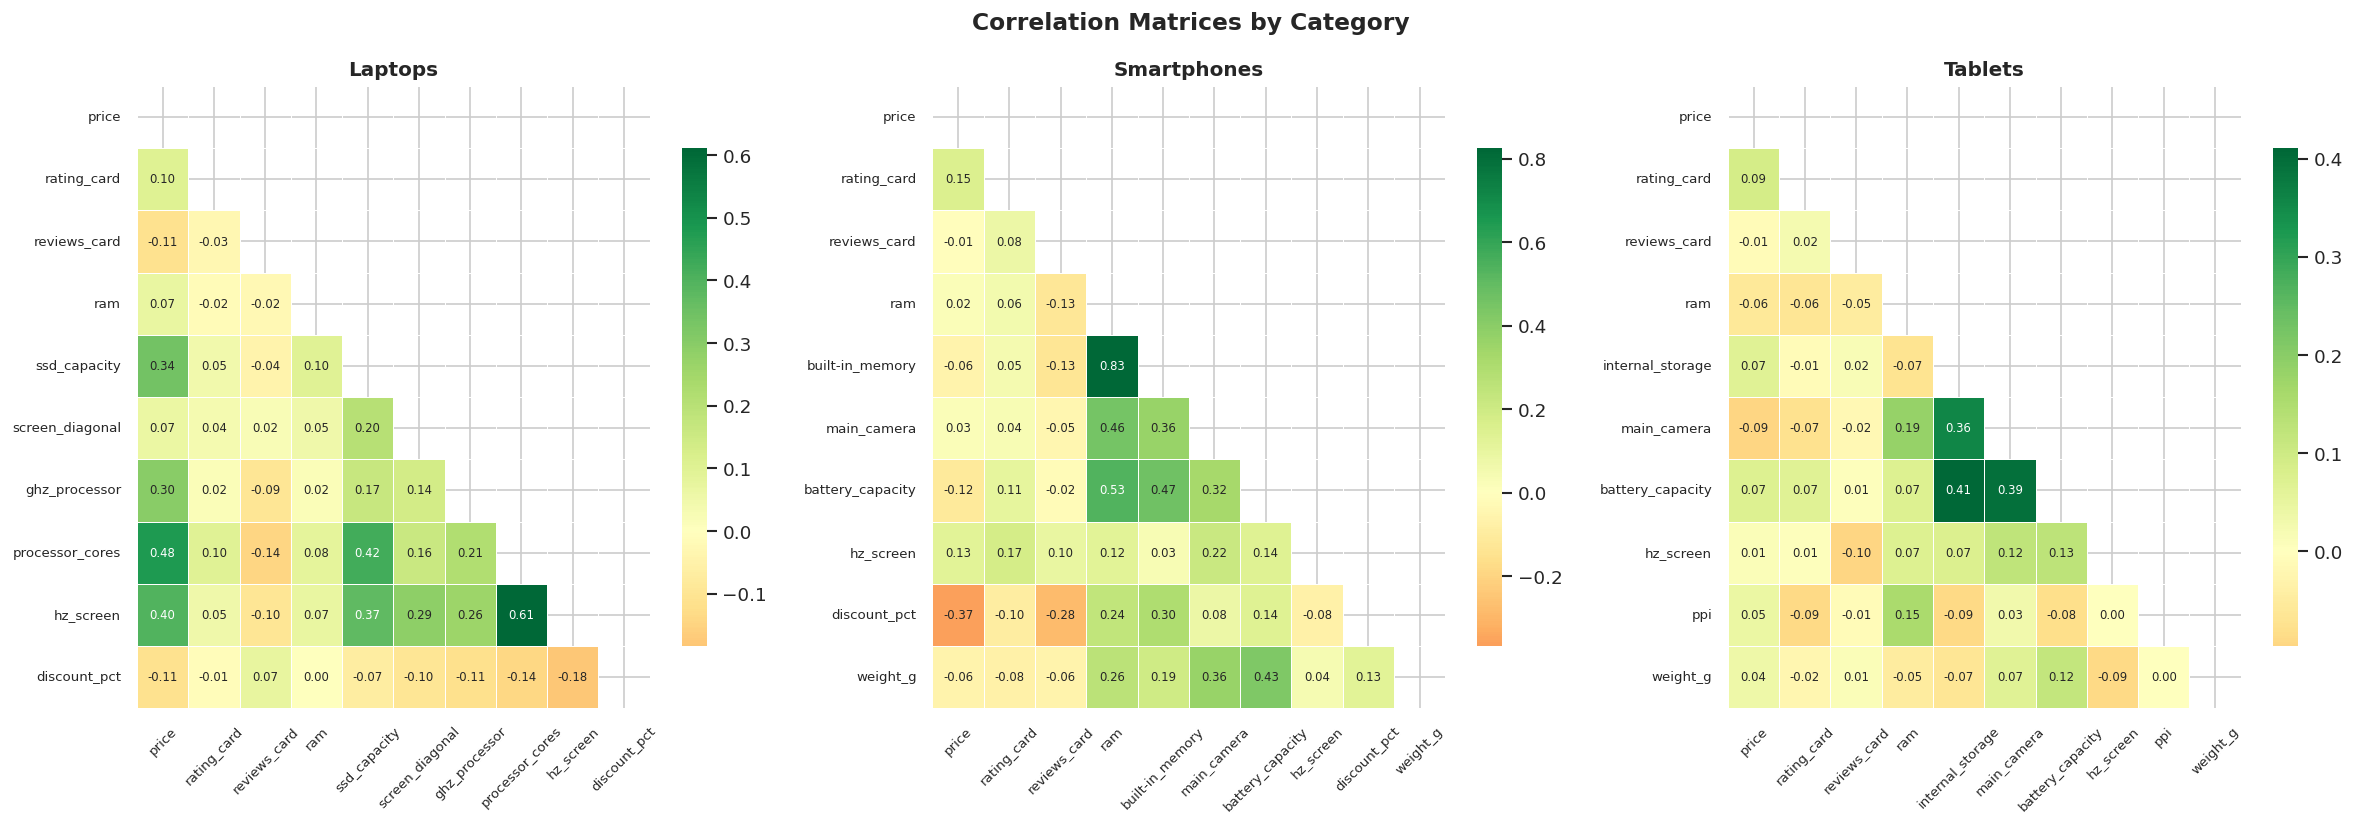

In [195]:
fig, axes = plt.subplots(1, 3, figsize=(20, 7))
fig.suptitle("Correlation Matrices by Category", fontsize=14, fontweight="bold")

corr_sets = [
    (df1, ["price","rating_card","reviews_card","ram","ssd_capacity",
           "screen_diagonal","ghz_processor","processor_cores","hz_screen","discount_pct"], "Laptops"),
    (df2, ["price","rating_card","reviews_card","ram","built-in_memory",
           "main_camera","battery_capacity","hz_screen","discount_pct","weight_g"], "Smartphones"),
    (df3, ["price","rating_card","reviews_card","ram","internal_storage",
           "main_camera","battery_capacity","hz_screen","ppi","weight_g"], "Tablets"),
]

for ax, (df_c, cols, title) in zip(axes, corr_sets):
    corr = df_c[cols].corr()
    mask = np.triu(np.ones_like(corr, dtype=bool))
    sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="RdYlGn",
                center=0, linewidths=0.4, ax=ax, annot_kws={"size":7},
                cbar_kws={"shrink":0.8})
    ax.set_title(title, fontsize=12, fontweight="bold")
    ax.tick_params(axis="x", labelsize=8, rotation=45)
    ax.tick_params(axis="y", labelsize=8)

plt.tight_layout(); plt.show()

In [232]:
# Top correlations with price
for df_c, cols, label in [
    (df1,["price","ram","ssd_capacity","screen_diagonal","ghz_processor","processor_cores","hz_screen","discount_pct","rating_card","reviews_card"],"Laptops"),
    (df2,["price","ram","built-in_memory","main_camera","battery_capacity","hz_screen","discount_pct","rating_card","weight_g"],"Smartphones"),
    (df3,["price","ram","internal_storage","main_camera","battery_capacity","hz_screen","ppi","rating_card","weight_g"],"Tablets"),
]:
    corr = df_c[cols].corr()["price"].drop("price").sort_values(key=abs, ascending=False)
    print(f"{label} — correlations with price:")
    for col, val in corr.items():
        bar = "█" * int(abs(val)*18)
        sign = "+" if val > 0 else "-"
        print(f"    {sign}{abs(val):.3f}  {bar:<18}  {col}")

Laptops — correlations with price:
    +0.478  ████████            processor_cores
    +0.397  ███████             hz_screen
    +0.341  ██████              ssd_capacity
    +0.299  █████               ghz_processor
    -0.111  █                   reviews_card
    -0.110  █                   discount_pct
    +0.103  █                   rating_card
    +0.069  █                   ram
    +0.066  █                   screen_diagonal
Smartphones — correlations with price:
    -0.368  ██████              discount_pct
    +0.153  ██                  rating_card
    +0.129  ██                  hz_screen
    -0.115  ██                  battery_capacity
    -0.064  █                   weight_g
    -0.059  █                   built-in_memory
    +0.025                      main_camera
    +0.023                      ram
Tablets — correlations with price:
    -0.095  █                   main_camera
    +0.088  █                   rating_card
    +0.072  █                   battery_capacity
    +0

In [233]:
# Average price by OS (laptops)
print("Laptops — average price by OS:")
display(df1.groupby("os")["price"].agg(["mean","median","count"]).sort_values("median", ascending=False).round(0))

Laptops — average price by OS:


,mean,median,count
os,,,
MacOS,847555.0,555964.0,399
Linux,409761.0,424220.0,46
Windows Pro,398312.0,424220.0,1957
Windows Home,556106.0,424220.0,1049
no_data,411739.0,424220.0,680
Без системы,500343.0,424220.0,1239
Ubuntu,325574.0,325574.0,1
Chrome OS,63358.0,59679.0,5


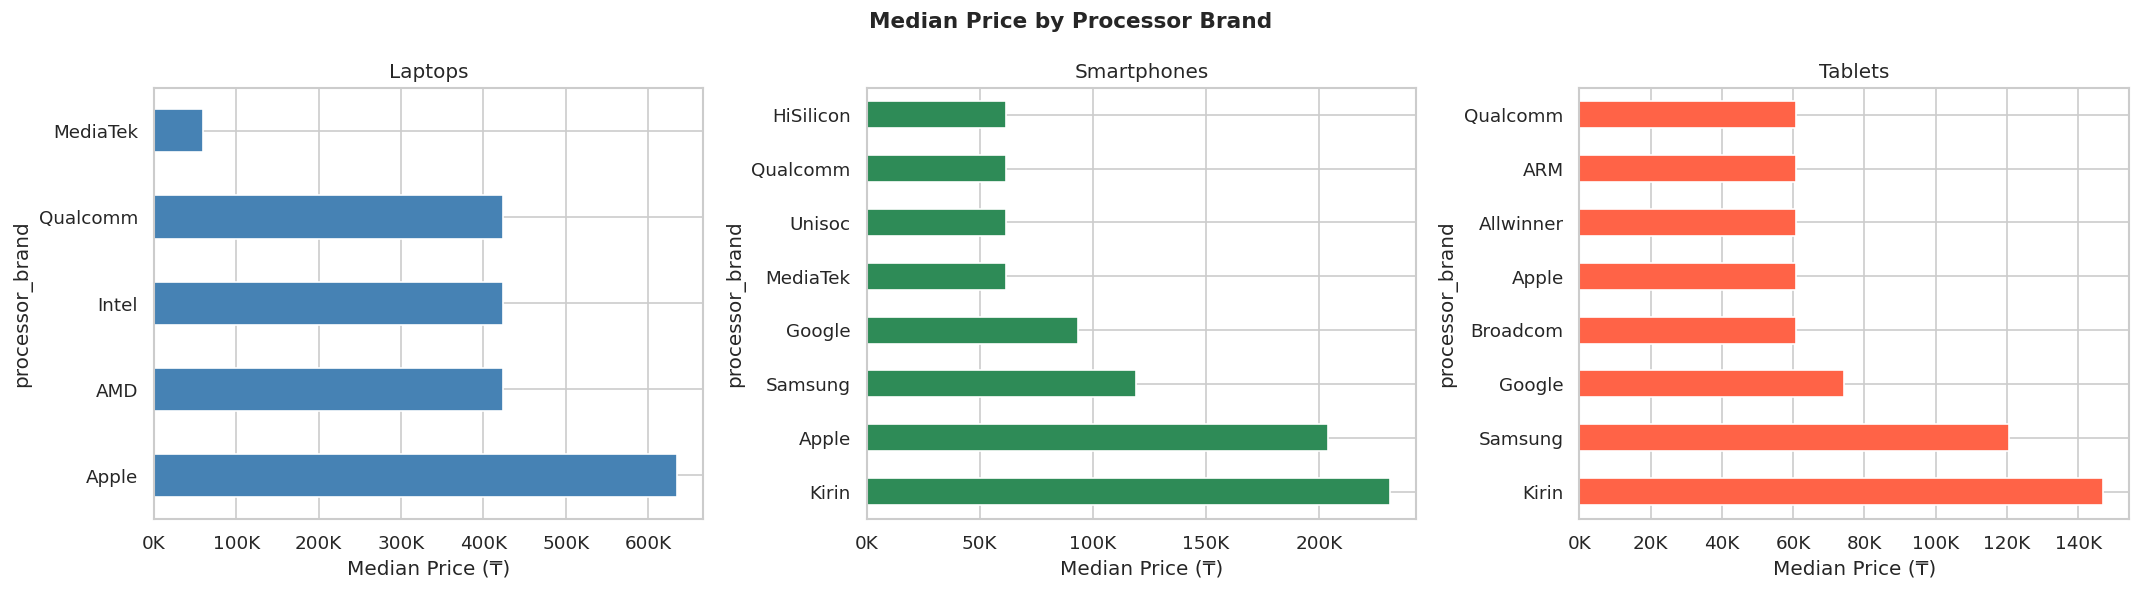

In [234]:
# Average price by processor brand
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Median Price by Processor Brand", fontsize=13, fontweight="bold")

for ax, (df_c, label, color) in zip(axes, [
    (df1,"Laptops","steelblue"),
    (df2,"Smartphones","seagreen"),
    (df3,"Tablets","tomato")
]):
    grp = df_c[df_c["processor_brand"] != "no_data"].groupby("processor_brand")["price"].median().sort_values(ascending=False).head(8)
    grp.plot(kind="barh", ax=ax, color=color, edgecolor="white")
    ax.set_title(label)
    ax.set_xlabel("Median Price (₸)")
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1000:.0f}K"))
plt.tight_layout(); plt.show()

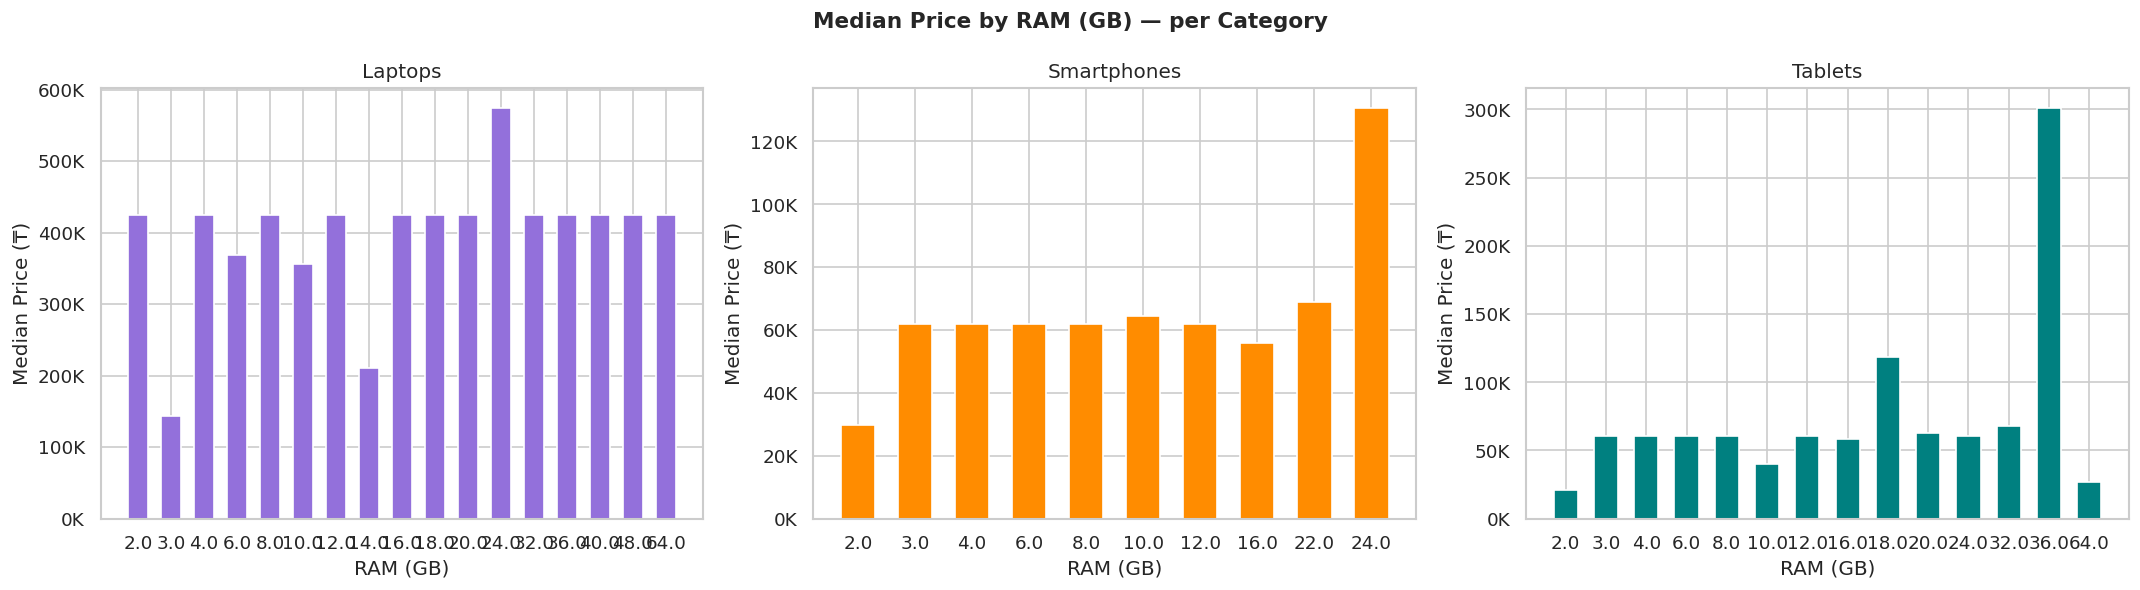

In [235]:
# RAM tier vs price (all three categories)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Median Price by RAM (GB) — per Category", fontsize=13, fontweight="bold")

for ax, (df_c, label, color) in zip(axes, [
    (df1,"Laptops","mediumpurple"),
    (df2,"Smartphones","darkorange"),
    (df3,"Tablets","teal")
]):
    grp = df_c.groupby("ram")["price"].median().reset_index()
    grp = grp[grp["ram"].between(2,64)].sort_values("ram")
    ax.bar(grp["ram"].astype(str), grp["price"], color=color, edgecolor="white", width=0.6)
    ax.set_title(label)
    ax.set_xlabel("RAM (GB)")
    ax.set_ylabel("Median Price (₸)")
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1000:.0f}K"))
plt.tight_layout(); plt.show()

In [236]:
# Rating and reviews by category
combined = {"laptops": df1, "smartphones": df2, "tablets": df3}
rows = []
for cat, df_c in combined.items():
    rows.append({
        "category":     cat,
        "median_price": df_c["price"].median(),
        "mean_rating":  df_c["rating_card"].mean(),
        "median_reviews":df_c["reviews_card"].median(),
        "mean_discount": df_c["discount_pct"].mean() if "discount_pct" in df_c.columns else None,
    })
summary_df = pd.DataFrame(rows).set_index("category").round(2)
print("Summary across categories:")
display(summary_df)

Summary across categories:


,median_price,mean_rating,median_reviews,mean_discount
category,,,,
laptops,424220.0,4.86,30.0,49.97
smartphones,61762.0,4.70,63.0,69.93
tablets,60747.5,4.78,33.0,71.89


In [201]:
pd.set_option("display.max_colwidth", 55)

print("TOP-10 most expensive laptops:")
display(df1.nlargest(10, "price")[["name_card","price","rating_card","ram","ssd_capacity","processor_brand"]])

▲ TOP-10 самых дорогих ноутбуков:


,name_card,price,rating_card,ram,ssd_capacity,processor_brand
4473,"Apple MacBook Pro 16 M4 Max 128GB RAM, 2TB SSD, Sta...",4920407.0,5.0,128.0,2048.0,Apple
4646,"Apple MacBook Pro 16 M4 Max 128GB RAM, 2TB SSD, Sta...",4920407.0,5.0,128.0,2048.0,Apple
4918,"Apple MacBook Pro 16 M4 Max 128GB RAM, 1TB SSD, Sta...",4610239.0,5.0,128.0,1024.0,Apple
2951,"Apple MacBook Pro 16 M4 Max 128GB RAM, 1TB SSD, Sta...",4531862.0,5.0,128.0,1024.0,Apple
2684,"Apple MacBook Pro 16 2026 Ноутбук 16.2"", Apple M5 M...",4336463.0,4.9,48.0,2048.0,Apple
1262,"Apple MacBook Pro 14 2026 Ноутбук 14.2"", Apple M5 M...",4044425.0,4.9,36.0,2048.0,Apple
3634,"Lenovo Legion 9 Gen 10 Игровой ноутбук 18"", Intel C...",3907844.0,4.9,64.0,2048.0,Intel
3839,Dell Alienware 18 Area-51 экран 2560x1600 300Hz Игр...,3429411.0,4.9,64.0,2048.0,Intel
1953,"Apple MacBook Pro 16 M5 Max 2026 Ноутбук 16.2"", RAM...",3320388.0,4.9,36.0,2048.0,Apple
2420,"Acer Predator Helios 16 AI Игровой ноутбук 16"", Int...",3312472.0,4.9,64.0,2048.0,Intel


In [237]:
print("TOP-10 most expensive smartphones:")
display(df2.nlargest(10, "price")[["name_card","price","rating_card","ram","built-in_memory","main_camera"]])

TOP-10 most expensive smartphones:


,name_card,price,rating_card,ram,built-in_memory,main_camera
2644,"Apple Смартфон iPhone 17 Pro Max, Dual: nano SIM + ...",1446336.0,4.9,12.0,2048.0,48.0
1039,Samsung Смартфон Galaxy S26 Ultra Ростест (EAC) 16/...,1327904.0,4.9,16.0,1024.0,200.0
1951,Samsung Смартфон Galaxy S26 Ultra Ростест (EAC) 16/...,1327904.0,4.9,16.0,1024.0,200.0
5254,Samsung Смартфон Galaxy S26 Ultra Ростест (EAC) 16/...,1327904.0,4.9,16.0,1024.0,200.0
1256,Samsung Смартфон Galaxy S26 Ultra Ростест (EAC) 16/...,1322423.0,4.9,16.0,1024.0,200.0
1030,"Apple Смартфон iPhone 17 Pro, Dual: nano SIM + eSIM...",1235916.0,5.0,12.0,1024.0,48.0
2815,"Apple Смартфон iPhone 17 Pro, Dual: nano SIM + eSIM...",1235916.0,5.0,12.0,1024.0,48.0
3454,"Apple Смартфон iPhone 17 Pro Max, Dual: nano SIM + ...",1227780.0,4.9,12.0,1024.0,48.0
1536,"Apple Смартфон iPhone 17 Pro Max, Dual: nano SIM + ...",1210969.0,4.9,12.0,1024.0,48.0
984,"Apple Смартфон iPhone 17 Pro, Dual: nano SIM + eSIM...",1180059.0,4.8,12.0,1024.0,48.0


In [240]:
print("TOP-10 most reviewed — laptops:")
display(df1.nlargest(10, "reviews_card")[["name_card","price","rating_card","reviews_card","processor_brand"]])

TOP-10 most reviewed — laptops:


,name_card,price,rating_card,reviews_card,processor_brand
4814,"Compolis для работы Ноутбук 14"", Intel Pentium N370...",174767.0,4.9,4706.0,Intel
2543,"Compolis для работы Ноутбук 15.6"", Intel Pentium N5...",231666.0,4.9,4705.0,Intel
4001,"Compolis для учебы и работы Ноутбук 15.6"", Intel Ce...",207934.0,4.9,4705.0,Intel
2459,"Compolis Ноутбук 16.1"", Intel N95, RAM 16 ГБ, SSD 5...",290809.0,4.9,4704.0,Intel
1611,"Compolis для учебы и работы Ноутбук 15.6"", Intel Pe...",218141.0,4.9,4703.0,Intel
318,"Compolis для учебы и работы Ноутбук 15.6"", Intel N9...",207036.0,4.9,4702.0,Intel
5317,"SkyX Ноутбук для работы и учебы Ноутбук 15.6"", RAM...",424220.0,4.8,4194.0,Intel
167,"Azerty RB-1799 Ноутбук 18.5"", Intel N95, RAM 16 ГБ,...",316988.0,4.8,3224.0,Intel
206,Azerty RBA-2810 игровой мощный с большим экраном Но...,486183.0,4.8,3224.0,AMD
563,"Azerty RB-1556 Ноутбук 15.6"", Intel Processor N100,...",192145.0,4.8,3224.0,Intel


In [239]:
print("TOP-10 most reviewed — smartphones:")
display(df2.nlargest(10, "reviews_card")[["name_card","price","rating_card","reviews_card","ram"]])

TOP-10 most reviewed — smartphones:


,name_card,price,rating_card,reviews_card,ram
4992,"Xiaomi Смартфон Redmi A5 Ростест (EAC) 4/128 ГБ, зе...",52816.0,4.9,26607.0,4.0
5052,"Xiaomi Смартфон Redmi A5 Ростест (EAC) 4/128 ГБ, че...",52816.0,4.9,26607.0,4.0
5065,"Xiaomi Смартфон Redmi A5 Ростест (EAC) 3/64 ГБ, черный",44003.0,4.9,26607.0,3.0
2453,"Xiaomi Смартфон Redmi A5 Ростест (EAC) 3/64 ГБ, зол...",43993.0,4.9,26596.0,3.0
2577,"Xiaomi Смартфон Redmi A5 Ростест (EAC) 4/128 ГБ, зо...",52816.0,4.9,26596.0,4.0
3510,"Xiaomi Смартфон Redmi A5 3/64 ГБ, голубой",43993.0,4.9,26596.0,3.0
846,"Xiaomi Смартфон Redmi A5 3/64 ГБ, зеленый",43993.0,4.9,26594.0,3.0
1479,"Xiaomi Смартфон Redmi A5 Ростест (EAC) 4/128 ГБ, го...",52385.0,4.9,26594.0,4.0
4149,"Xiaomi Смартфон Redmi 15C Ростест (EAC) 8/256 ГБ, о...",76071.0,4.9,15339.0,8.0
3938,"Xiaomi Смартфон Redmi 15C Ростест (EAC) 8/256 ГБ, ч...",76310.0,4.9,15338.0,8.0


In [205]:
print("TOP-10 наибольший дисконт — ноутбуки:")
display(df1.nlargest(10, "discount_pct")[["name_card","price","price_old","discount_pct","os"]])

💸 TOP-10 наибольший дисконт — ноутбуки:


,name_card,price,price_old,discount_pct,os
3323,"W&O Ноутбук 15.6"", RAM 8 ГБ, SSD 215 ГБ, Windows Pr...",139803.0,3021480.0,95.37,Windows Pro
2781,"W&O Ноутбук 15.6"", Intel Core i3-10100, RAM 16 ГБ, ...",211820.0,4279771.0,95.05,Windows Pro
4803,"W&O Ноутбук 15.6"", Intel Celeron N5095, RAM 16 ГБ, ...",158304.0,3052406.0,94.81,Windows Pro
4780,"Lenozon Игровой ноутбук 16"", Intel Core i7-6700HQ, ...",480596.0,6386942.0,92.48,Windows Pro
1105,"MAIBENBEN S14B-R560UM Ноутбук 14.5"", AMD Ryzen 5 66...",429839.0,5181788.0,91.70,Windows Home
3632,"MAIBENBEN Medio M657 M6571SB0LURE3 Ноутбук 16"", AMD...",370467.0,4365315.0,91.51,Windows Home
3255,"Ноутбук 15.6"" Full HD, N5095A, 16 ГБ ОЗУ, 512 ГБ SS...",153498.0,1650379.0,90.70,Windows Pro
2015,"Apple MacBook Air 13 2026 M5 Ноутбук 13.6"", Apple M...",1069657.0,11409787.0,90.63,MacOS
272,"Apple MacBook Air 15 M5 Ноутбук 15.3"", Apple M5 (10...",1075698.0,11410829.0,90.57,MacOS
964,"Apple MacBook Pro 14 M5 2025 Ноутбук 14.2"", RAM 24 ...",1448242.0,15217546.0,90.48,MacOS


In [238]:
print("TOP-10 highest discount — laptops:")
display(df1.nlargest(10, "discount_pct")[["name_card","price","price_old","discount_pct","os"]])

TOP-10 highest discount — laptops:


,name_card,price,price_old,discount_pct,os
3323,"W&O Ноутбук 15.6"", RAM 8 ГБ, SSD 215 ГБ, Windows Pr...",139803.0,3021480.0,95.37,Windows Pro
2781,"W&O Ноутбук 15.6"", Intel Core i3-10100, RAM 16 ГБ, ...",211820.0,4279771.0,95.05,Windows Pro
4803,"W&O Ноутбук 15.6"", Intel Celeron N5095, RAM 16 ГБ, ...",158304.0,3052406.0,94.81,Windows Pro
4780,"Lenozon Игровой ноутбук 16"", Intel Core i7-6700HQ, ...",480596.0,6386942.0,92.48,Windows Pro
1105,"MAIBENBEN S14B-R560UM Ноутбук 14.5"", AMD Ryzen 5 66...",429839.0,5181788.0,91.70,Windows Home
3632,"MAIBENBEN Medio M657 M6571SB0LURE3 Ноутбук 16"", AMD...",370467.0,4365315.0,91.51,Windows Home
3255,"Ноутбук 15.6"" Full HD, N5095A, 16 ГБ ОЗУ, 512 ГБ SS...",153498.0,1650379.0,90.70,Windows Pro
2015,"Apple MacBook Air 13 2026 M5 Ноутбук 13.6"", Apple M...",1069657.0,11409787.0,90.63,MacOS
272,"Apple MacBook Air 15 M5 Ноутбук 15.3"", Apple M5 (10...",1075698.0,11410829.0,90.57,MacOS
964,"Apple MacBook Pro 14 M5 2025 Ноутбук 14.2"", RAM 24 ...",1448242.0,15217546.0,90.48,MacOS


Mann-Whitney U = 1778728,  p = 0.000000
Median — Discrete: 424,220  |  Integrated: 424,220
-> CONFIRMED — discrete GPU is significantly more expensive


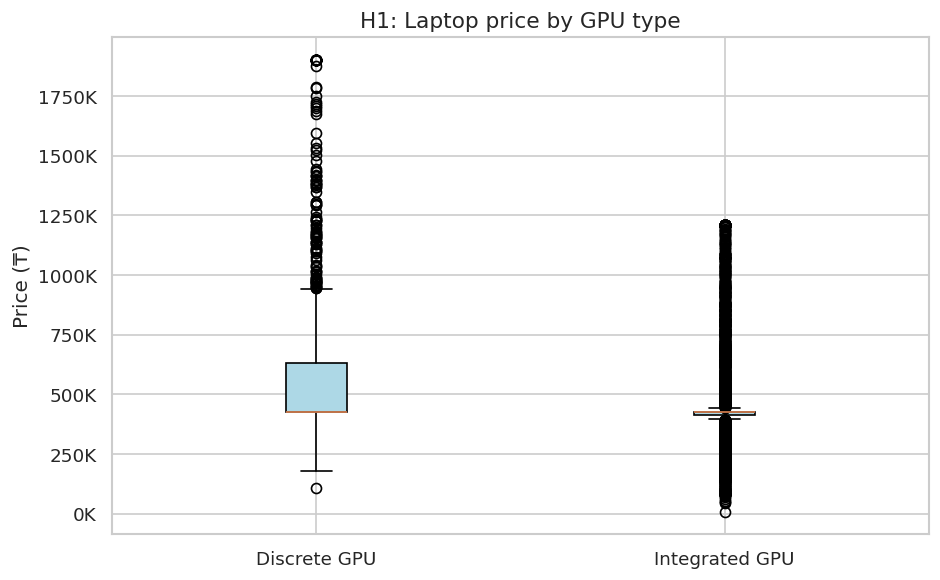

In [246]:
discrete = df1[df1["gpu_type"] == "Дискретная"]["price"].dropna()
integrated = df1[df1["gpu_type"] == "Встроенная"]["price"].dropna()

stat, p = stats.mannwhitneyu(discrete, integrated, alternative="greater")
print(f"Mann-Whitney U = {stat:.0f},  p = {p:.6f}")
print(f"Median — Discrete: {discrete.median():,.0f}  |  Integrated: {integrated.median():,.0f}")
print(f"-> {'CONFIRMED — discrete GPU is significantly more expensive' if p < 0.05 else 'NOT confirmed'}")

fig, ax = plt.subplots(figsize=(8,5))
ax.boxplot([discrete.clip(0, discrete.quantile(0.97)), integrated.clip(0, integrated.quantile(0.97))],
           labels=["Discrete GPU","Integrated GPU"], patch_artist=True,
           boxprops=dict(facecolor="lightblue"))
ax.set_title("H1: Laptop price by GPU type", fontsize=13)
ax.set_ylabel("Price (₸)")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1000:.0f}K"))
plt.tight_layout(); plt.show()

Spearman ρ = -0.156,  p = 0.000000
-> Weak or not significant


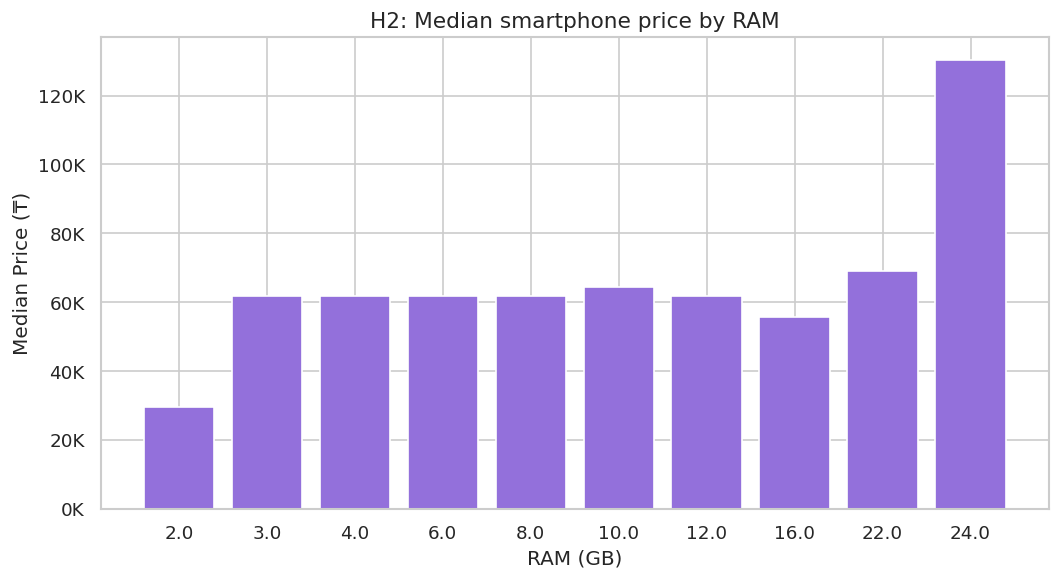

In [249]:
rho, p = stats.spearmanr(df2["ram"].dropna(), df2.loc[df2["ram"].notna(),"price"])
print(f"Spearman ρ = {rho:.3f},  p = {p:.6f}")
print(f"-> {'CONFIRMED — strong positive correlation' if p < 0.05 and rho > 0.3 else 'Weak or not significant'}")

fig, ax = plt.subplots(figsize=(9,5))
ram_price = df2.groupby("ram")["price"].median().reset_index()
ram_price = ram_price[ram_price["ram"].between(2,24)]
ax.bar(ram_price["ram"].astype(str), ram_price["price"], color="mediumpurple", edgecolor="white")
ax.set_title("H2: Median smartphone price by RAM", fontsize=13)
ax.set_xlabel("RAM (GB)")
ax.set_ylabel("Median Price (₸)")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1000:.0f}K"))
plt.tight_layout(); plt.show()

,Category,p,med_high,med_low,Result
0,Laptops,0.0,30.0,3.0,yes
1,Smartphones,0.0,63.0,17.0,yes
2,Tablets,0.0,33.0,14.5,yes


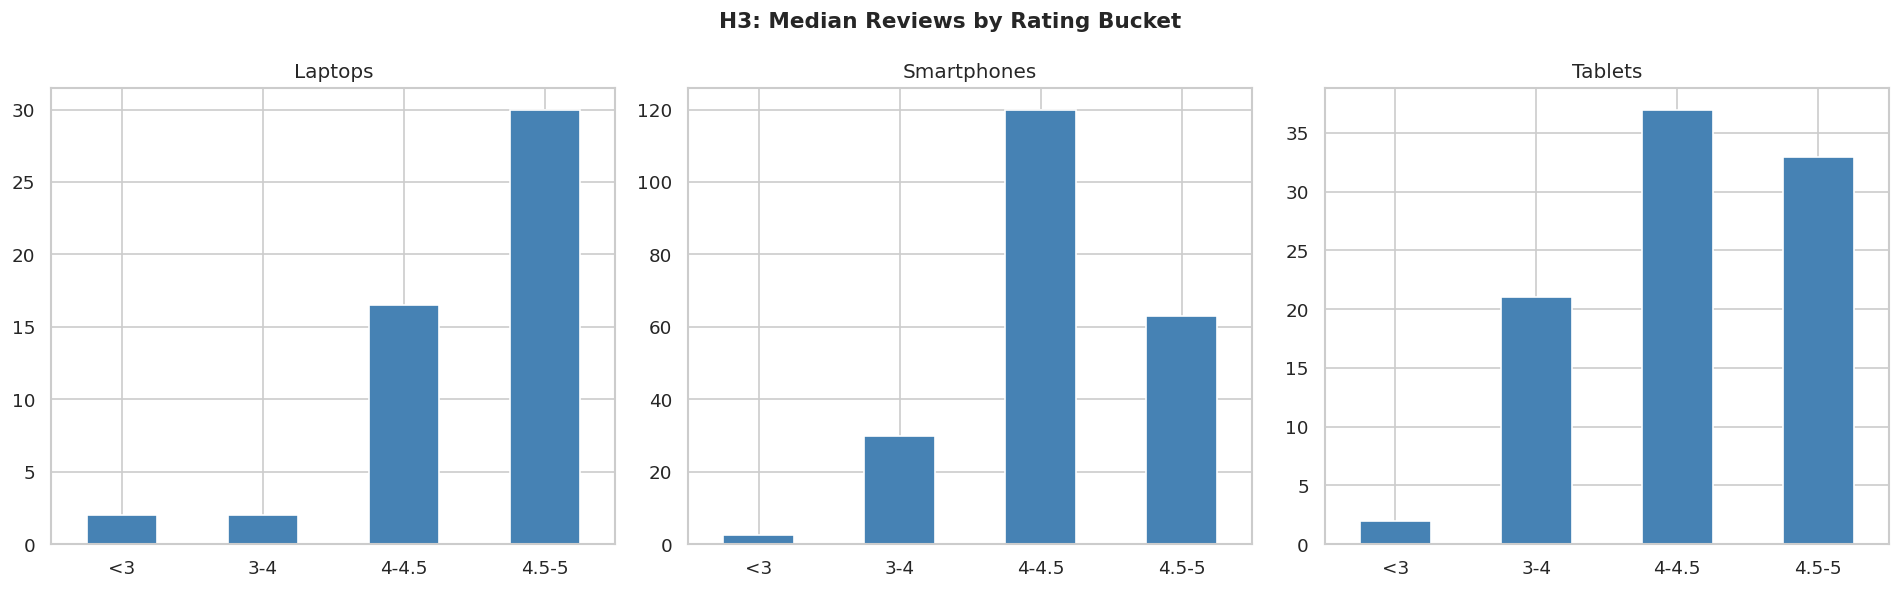

In [250]:
results = []
for label, df_c in [("Laptops",df1),("Smartphones",df2),("Tablets",df3)]:
    high = df_c[df_c["rating_card"] >= 4.5]["reviews_card"].dropna()
    low  = df_c[df_c["rating_card"] <  4.0]["reviews_card"].dropna()
    if len(high) > 10 and len(low) > 10:
        stat, p = stats.mannwhitneyu(high, low, alternative="greater")
        results.append({"Category":label, "p":round(p,4), "med_high":high.median(), "med_low":low.median(),
                        "Result":"yes" if p<0.05 else "no"})

display(pd.DataFrame(results))

# Visualization
fig, axes = plt.subplots(1,3, figsize=(16,5))
fig.suptitle("H3: Median Reviews by Rating Bucket", fontsize=13, fontweight="bold")
for ax, (label, df_c) in zip(axes,[("Laptops",df1),("Smartphones",df2),("Tablets",df3)]):
    df_c["rating_bucket"] = pd.cut(df_c["rating_card"], bins=[0,3,4,4.5,5], labels=["<3","3-4","4-4.5","4.5-5"])
    bkt = df_c.groupby("rating_bucket", observed=True)["reviews_card"].median()
    bkt.plot(kind="bar", ax=ax, edgecolor="white", color="steelblue")
    ax.set_title(label); ax.set_xlabel(""); ax.tick_params(axis="x",rotation=0)
plt.tight_layout(); plt.show()

In [253]:
print(f"{'Category':<14} {'rho':>7}  {'p':>9}  Result")
print("-"*55)
for label, df_c in [("Laptops",df1),("Smartphones",df2),("Tablets",df3)]:
    if "discount_pct" not in df_c.columns: continue
    valid = df_c[["discount_pct","rating_card"]].dropna()
    rho, p = stats.spearmanr(valid["discount_pct"], valid["rating_card"])
    direction = "-> higher rating" if rho > 0 else "-> lower rating"
    sig = f"significant ({direction})" if p < 0.05 else "not significant"
    print(f"{label:<14} {rho:>7.3f}  {p:>9.4f}  {sig}")

Category           rho          p  Result
-------------------------------------------------------
Laptops         -0.020     0.1511  not significant
Smartphones     -0.075     0.0000  significant (-> lower rating)
Tablets          0.000     0.9890  not significant


In [255]:
# Insight 1: Price != Rating
print(" INSIGHT 1: Price and rating barely correlate")
for label, df_c in [("Laptops",df1),("Smartphones",df2),("Tablets",df3)]:
    rho, _ = stats.spearmanr(df_c["price"].dropna(), df_c.loc[df_c["price"].notna(),"rating_card"])
    print(f"   {label}: ρ = {rho:.3f}  -> expensive != high quality")

 INSIGHT 1: Price and rating barely correlate
   Laptops: ρ = 0.345  -> expensive != high quality
   Smartphones: ρ = 0.273  -> expensive != high quality
   Tablets: ρ = 0.185  -> expensive != high quality


In [256]:
# Insight 2: Inflated discounts
print(" INSIGHT 2: Discounts appear artificially inflated")
for label, df_c in [("Laptops",df1),("Smartphones",df2)]:
    heavy = (df_c["discount_pct"] >= 50).mean() * 100
    med   = df_c["discount_pct"].median()
    print(f"   {label}: median discount = {med:.1f}%,  >=50% discount for {heavy:.1f}% of products")
print("   -> old_price is likely inflated by sellers to fake a deal")

 INSIGHT 2: Discounts appear artificially inflated
   Laptops: median discount = 49.2%,  >=50% discount for 22.3% of products
   Smartphones: median discount = 80.5%,  >=50% discount for 83.2% of products
   -> old_price is likely inflated by sellers to fake a deal


In [257]:
# Insight 3: Winner-takes-all in reviews
print(" INSIGHT 3: Winner-takes-all effect in reviews")
for label, df_c in [("Laptops",df1),("Smartphones",df2),("Tablets",df3)]:
    med = df_c["reviews_card"].median()
    top5 = df_c["reviews_card"].quantile(0.95)
    mx   = df_c["reviews_card"].max()
    print(f"   {label}: median={med:.0f}  top5%={top5:.0f}  max={mx:.0f}")
print("   -> Top 5% of products collect the majority of reviews")

 INSIGHT 3: Winner-takes-all effect in reviews
   Laptops: median=30  top5%=466  max=4706
   Smartphones: median=63  top5%=1939  max=26607
   Tablets: median=33  top5%=440  max=5355
   -> Top 5% of products collect the majority of reviews


In [258]:
# Insight 4: GPU type as main price driver for laptops
print(" INSIGHT 4: GPU type is the main price driver for laptops")
gpu_grp = df1[df1["gpu_type"] != "no_data"].groupby("gpu_type")["price"].median().sort_values(ascending=False)
for gpu, price in gpu_grp.items():
    print(f"   {gpu}: {price:,.0f} ₸")


 INSIGHT 4: GPU type is the main price driver for laptops
   Встроенная: 424,220 ₸
   Дискретная: 424,220 ₸
   Гибридная: 423,075 ₸


In [260]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

warnings.filterwarnings("ignore")

# Color palette
PALETTE = {"laptop": "#4C72B0", "smartphones": "#DD8452", "tablets": "#55A868"}
CAT_COLORS = ["#4C72B0", "#DD8452", "#55A868", "#C44E52", "#8172B2", "#937860"]
sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 120
plt.rcParams["axes.prop_cycle"] = plt.cycler(color=CAT_COLORS)

# Combined dataframe for shared charts
df_all = pd.concat([
    df1[["price","rating_card","reviews_card","ram","discount_pct","processor_brand"]].assign(category="laptop"),
    df2[["price","rating_card","reviews_card","ram","discount_pct","processor_brand"]].assign(category="smartphones"),
    df3[["price","rating_card","reviews_card","ram","processor_brand"]].assign(category="tablets"),
], ignore_index=True)
df_all["discount_pct"] = df_all["discount_pct"].fillna(0)

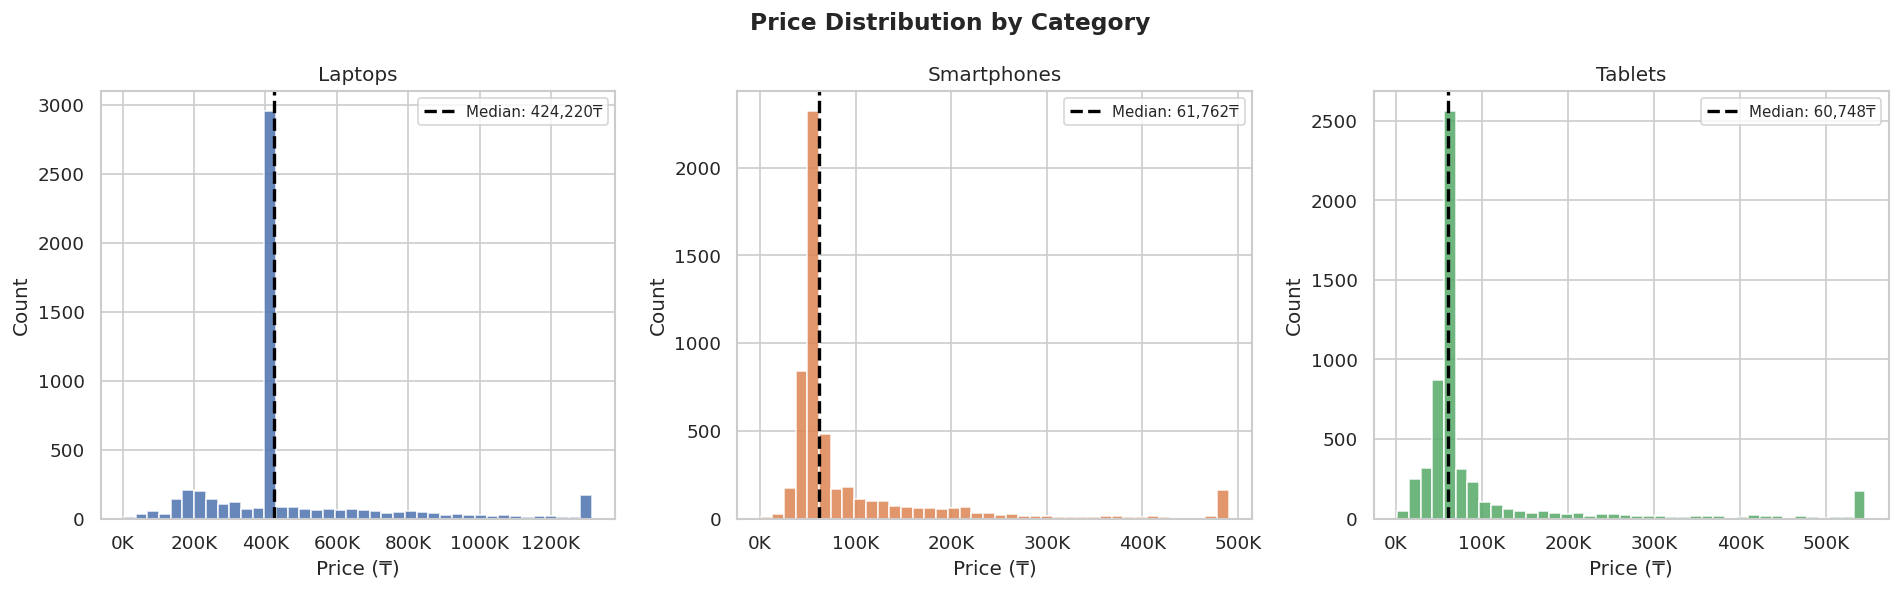

 Caption: Laptop prices are right-skewed with a long tail — most are under 500K, but the premium segment pulls the mean up significantly.


In [259]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Price Distribution by Category", fontsize=14, fontweight="bold")

for ax, (df_c, label, color) in zip(axes, [
    (df1, "Laptops",     "#4C72B0"),
    (df2, "Smartphones", "#DD8452"),
    (df3, "Tablets",     "#55A868"),
]):
    data = df_c["price"].dropna()
    data_clipped = data.clip(0, data.quantile(0.97))
    ax.hist(data_clipped, bins=40, color=color, alpha=0.85, edgecolor="white")
    ax.axvline(data.median(), color="black", lw=2, ls="--", label=f"Median: {data.median():,.0f}₸")
    ax.set_title(label, fontsize=12)
    ax.set_xlabel("Price (₸)")
    ax.set_ylabel("Count")
    ax.legend(fontsize=9)
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1000:.0f}K"))

plt.tight_layout()
plt.savefig("viz1_histogram_price.png", bbox_inches="tight")
plt.show()
print(" Caption: Laptop prices are right-skewed with a long tail — most are under 500K, but the premium segment pulls the mean up significantly.")

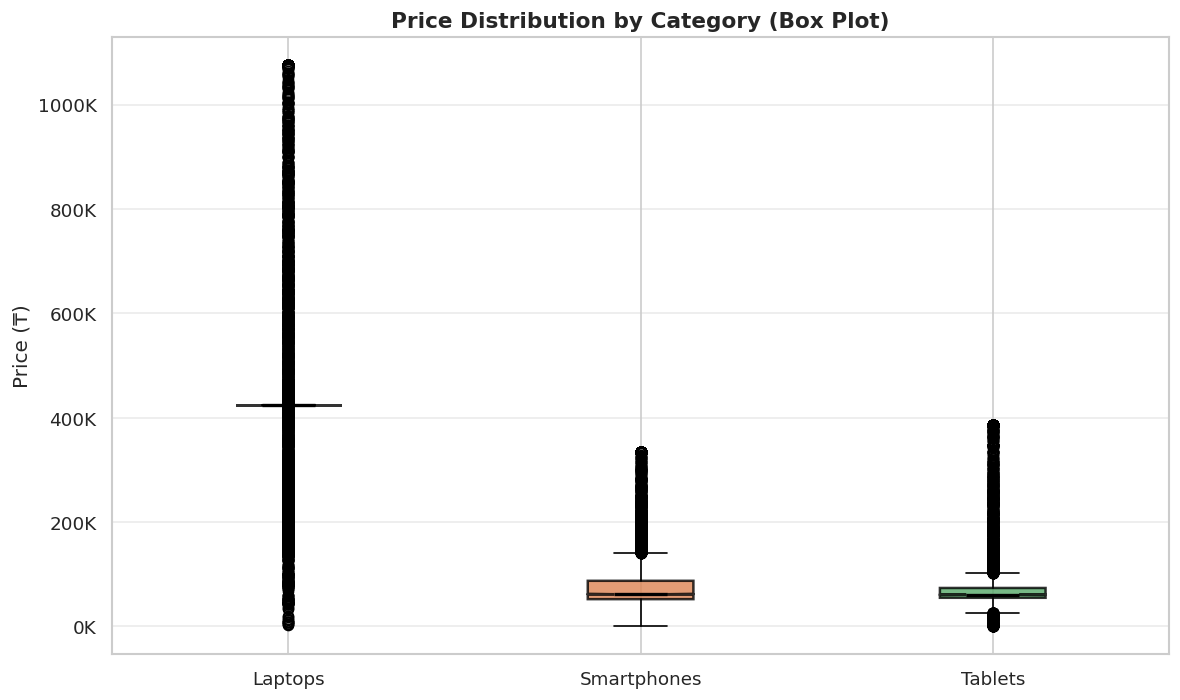

 Caption: Laptops have the widest price spread and highest median. Smartphones and tablets are closer in price range, but both have outliers.


In [261]:
fig, ax = plt.subplots(figsize=(10, 6))

data_box = [
    df1["price"].clip(0, df1["price"].quantile(0.95)).dropna(),
    df2["price"].clip(0, df2["price"].quantile(0.95)).dropna(),
    df3["price"].clip(0, df3["price"].quantile(0.95)).dropna(),
]
bp = ax.boxplot(data_box, labels=["Laptops", "Smartphones", "Tablets"],
                patch_artist=True, notch=True,
                boxprops=dict(linewidth=1.5),
                medianprops=dict(color="black", lw=2))

for patch, color in zip(bp["boxes"], ["#4C72B0", "#DD8452", "#55A868"]):
    patch.set_facecolor(color)
    patch.set_alpha(0.8)

ax.set_title("Price Distribution by Category (Box Plot)", fontsize=13, fontweight="bold")
ax.set_ylabel("Price (₸)")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1000:.0f}K"))
ax.grid(axis="y", alpha=0.4)

plt.tight_layout()
plt.savefig("viz2_boxplot_price.png", bbox_inches="tight")
plt.show()
print(" Caption: Laptops have the widest price spread and highest median. Smartphones and tablets are closer in price range, but both have outliers.")

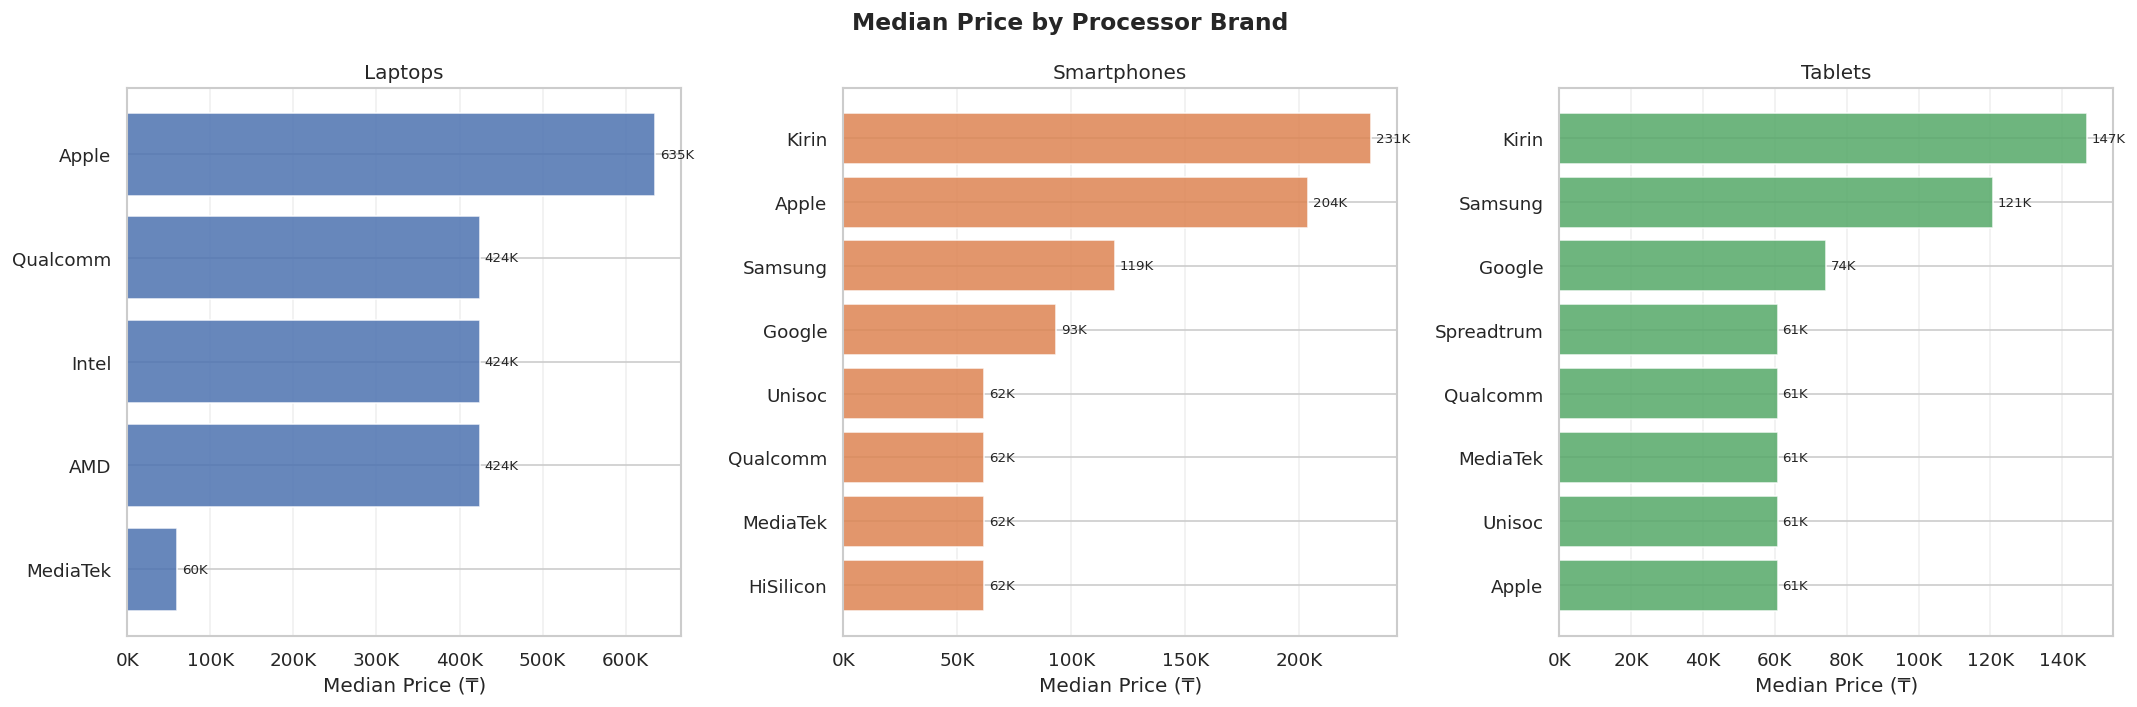

 Caption: Apple and AMD brands lead the top price segment for laptops. Apple also leads median price in smartphones, while Unisoc covers the budget tablet segment.


In [262]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle("Median Price by Processor Brand", fontsize=14, fontweight="bold")

for ax, (df_c, label, color) in zip(axes, [
    (df1, "Laptops",     "#4C72B0"),
    (df2, "Smartphones", "#DD8452"),
    (df3, "Tablets",     "#55A868"),
]):
    grp = (df_c[df_c["processor_brand"] != "no_data"]
           .groupby("processor_brand")["price"]
           .median()
           .sort_values(ascending=True)
           .tail(8))
    bars = ax.barh(grp.index, grp.values, color=color, edgecolor="white", alpha=0.85)
    ax.bar_label(bars, fmt=lambda x: f"{x/1000:.0f}K", padding=3, fontsize=8)
    ax.set_title(label, fontsize=12)
    ax.set_xlabel("Median Price (₸)")
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1000:.0f}K"))
    ax.grid(axis="x", alpha=0.3)

plt.tight_layout()
plt.savefig("viz3_bar_processor.png", bbox_inches="tight")
plt.show()
print(" Caption: Apple and AMD brands lead the top price segment for laptops. Apple also leads median price in smartphones, while Unisoc covers the budget tablet segment.")

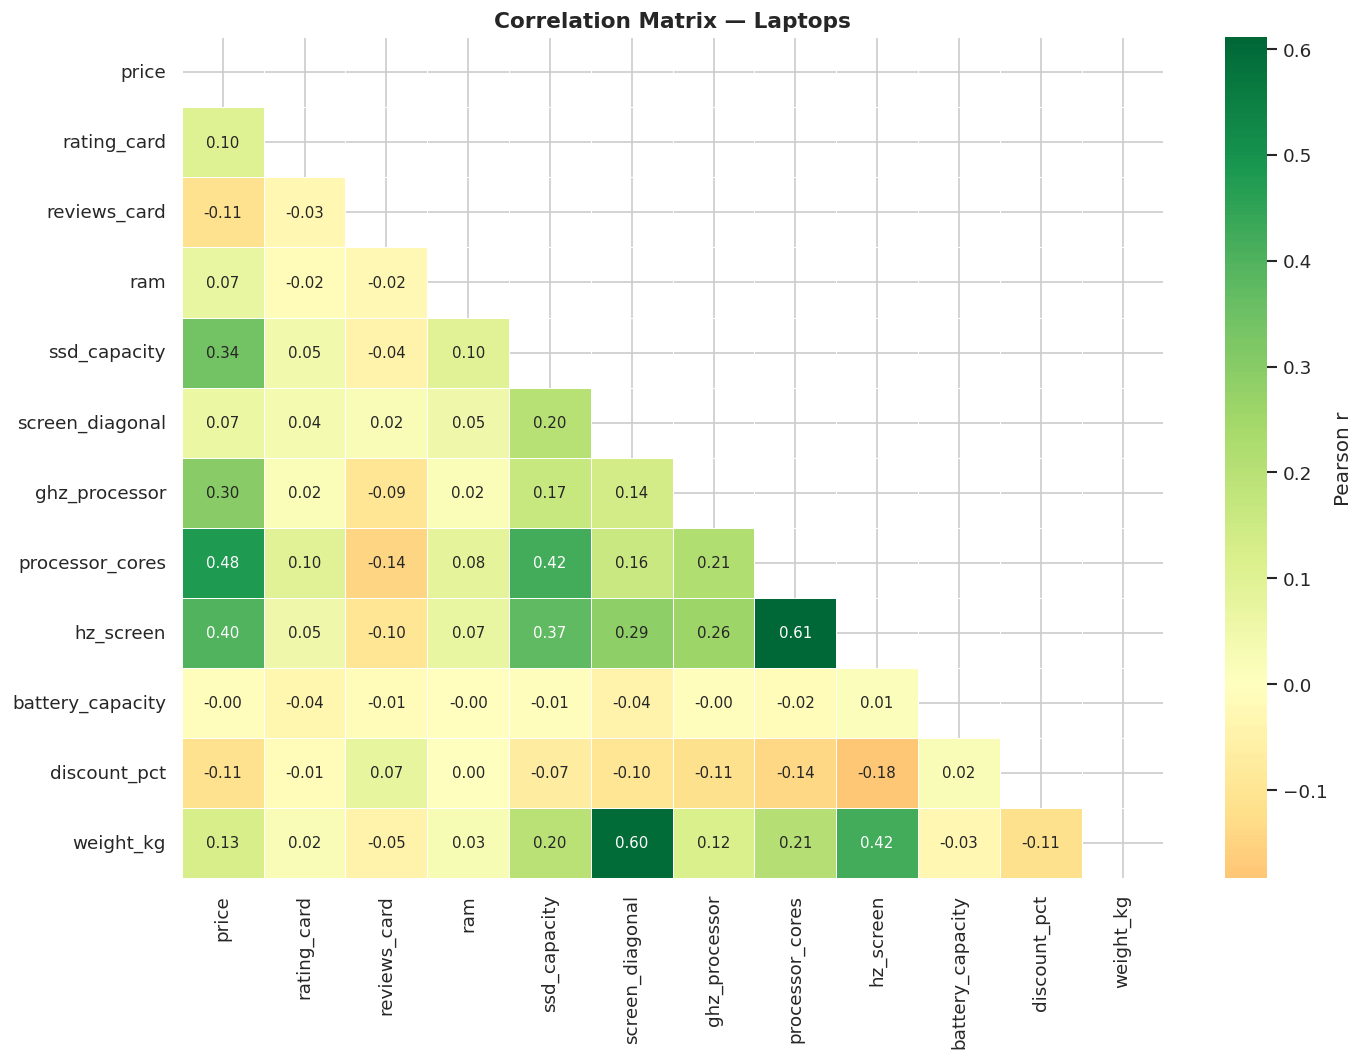

 Caption: RAM and SSD are the strongest positive correlators with laptop price (r>0.5). Discount_pct has weak correlation with rating — discounts are not linked to quality.


In [263]:
corr_cols = ["price","rating_card","reviews_card","ram","ssd_capacity",
             "screen_diagonal","ghz_processor","processor_cores","hz_screen",
             "battery_capacity","discount_pct","weight_kg"]

corr = df1[corr_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

fig, ax = plt.subplots(figsize=(12, 9))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="RdYlGn",
            center=0, linewidths=0.5, ax=ax, annot_kws={"size": 9},
            cbar_kws={"label": "Pearson r"})
ax.set_title("Correlation Matrix — Laptops", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("viz5_heatmap_laptops.png", bbox_inches="tight")
plt.show()
print(" Caption: RAM and SSD are the strongest positive correlators with laptop price (r>0.5). Discount_pct has weak correlation with rating — discounts are not linked to quality.")

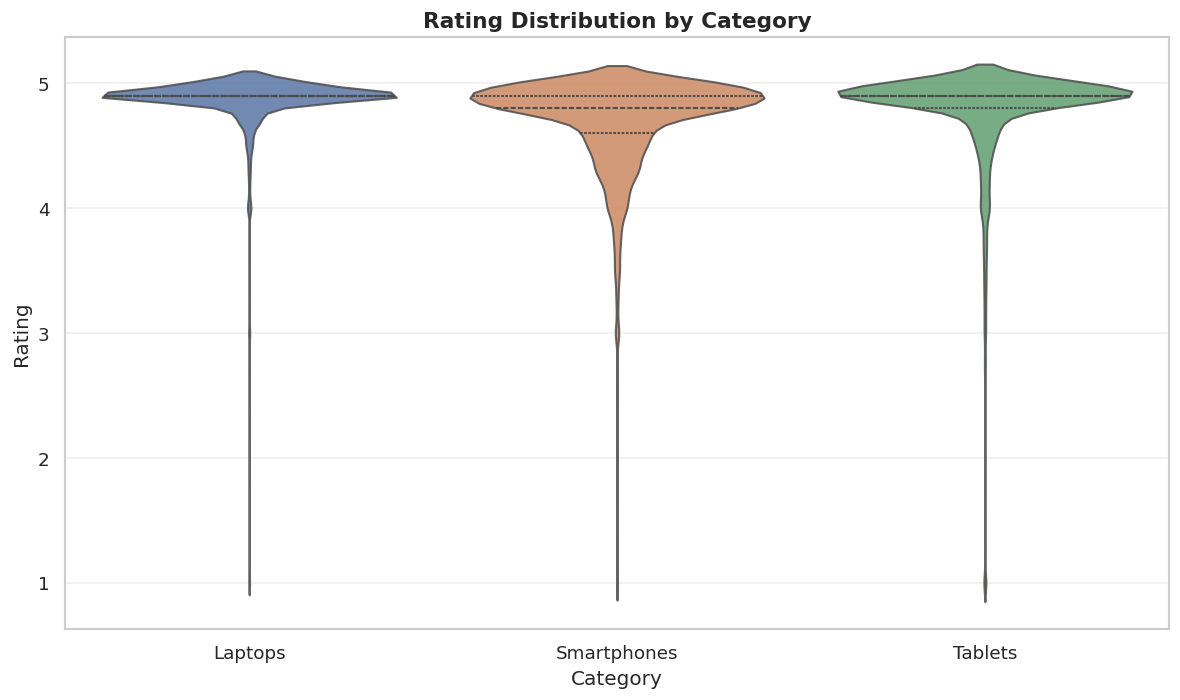

 Caption: All three categories show similar rating distributions concentrated around 4.5-5.0. Tablets show a slightly wider spread at lower values.


In [264]:
fig, ax = plt.subplots(figsize=(10, 6))

df_violin = df_all[["category","rating_card"]].dropna()
sns.violinplot(data=df_violin, x="category", y="rating_card",
               palette=PALETTE, inner="quartile", ax=ax, alpha=0.85)

ax.set_title("Rating Distribution by Category", fontsize=13, fontweight="bold")
ax.set_xlabel("Category")
ax.set_ylabel("Rating")
ax.set_xticklabels(["Laptops", "Smartphones", "Tablets"])
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig("viz6_violin_rating.png", bbox_inches="tight")
plt.show()
print(" Caption: All three categories show similar rating distributions concentrated around 4.5-5.0. Tablets show a slightly wider spread at lower values.")

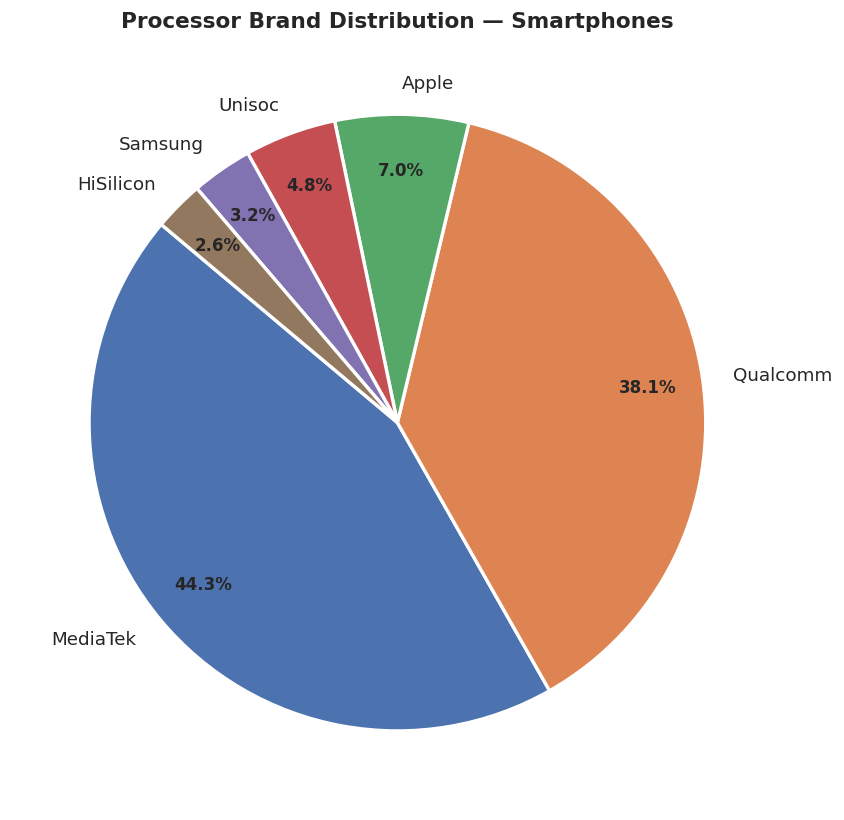

 Caption: Qualcomm and MediaTek dominate the Ozon.kz smartphone market with over 70% of listings. Apple holds a small but high-value niche.


In [265]:
brand_counts = (df2[df2["processor_brand"] != "no_data"]
                ["processor_brand"].value_counts().head(6))

fig, ax = plt.subplots(figsize=(9, 7))
wedges, texts, autotexts = ax.pie(
    brand_counts.values,
    labels=brand_counts.index,
    autopct="%1.1f%%",
    colors=CAT_COLORS,
    startangle=140,
    pctdistance=0.82,
    wedgeprops=dict(edgecolor="white", linewidth=2)
)
for text in autotexts:
    text.set_fontsize(10)
    text.set_fontweight("bold")

ax.set_title("Processor Brand Distribution — Smartphones", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("viz7_pie_processor.png", bbox_inches="tight")
plt.show()
print(" Caption: Qualcomm and MediaTek dominate the Ozon.kz smartphone market with over 70% of listings. Apple holds a small but high-value niche.")

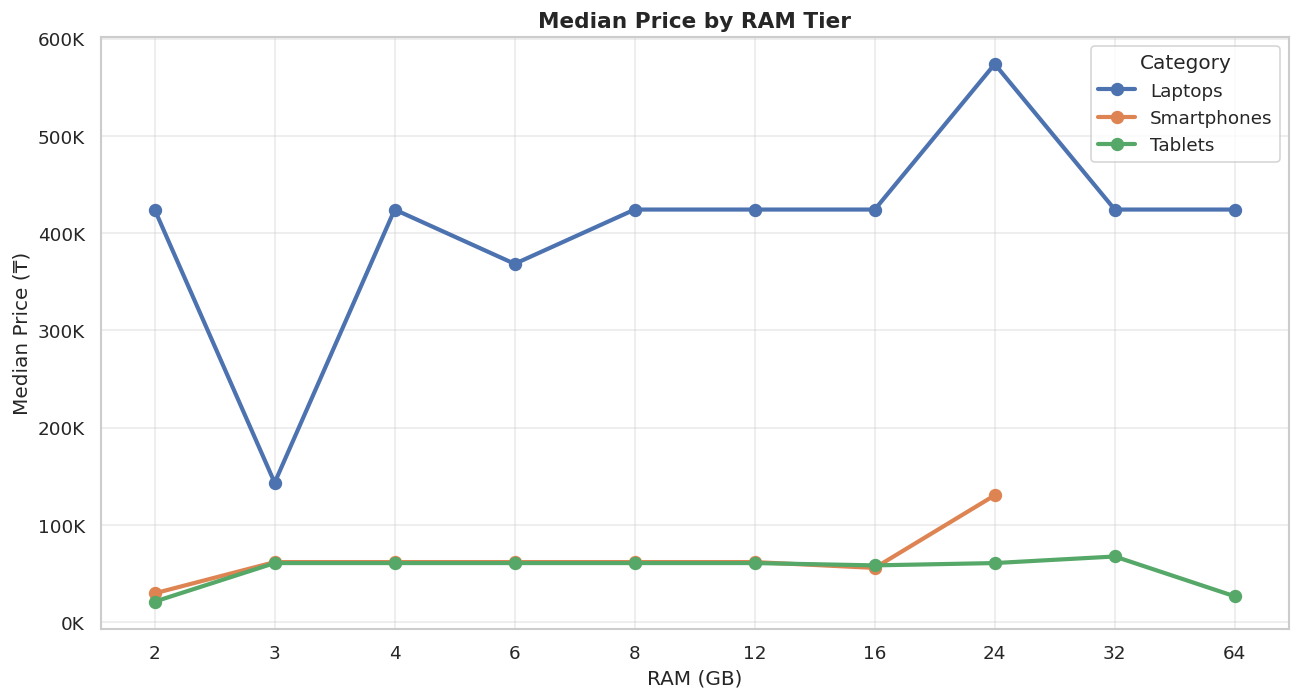

 Caption: All three categories show a clear price increase with more RAM. Laptops show the steepest growth from 8 to 16+ GB.


In [266]:
fig, ax = plt.subplots(figsize=(11, 6))

ram_range = [2, 3, 4, 6, 8, 12, 16, 24, 32, 64]

for df_c, label, color in [
    (df1, "Laptops",     "#4C72B0"),
    (df2, "Smartphones", "#DD8452"),
    (df3, "Tablets",     "#55A868"),
]:
    grp = (df_c[df_c["ram"].isin(ram_range)]
           .groupby("ram")["price"]
           .median()
           .reindex(ram_range))
    ax.plot(grp.index.astype(str), grp.values,
            marker="o", lw=2.5, color=color, label=label, markersize=7)

ax.set_title("Median Price by RAM Tier", fontsize=13, fontweight="bold")
ax.set_xlabel("RAM (GB)")
ax.set_ylabel("Median Price (₸)")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1000:.0f}K"))
ax.legend(title="Category")
ax.grid(alpha=0.4)

plt.tight_layout()
plt.savefig("viz8_line_ram_price.png", bbox_inches="tight")
plt.show()
print(" Caption: All three categories show a clear price increase with more RAM. Laptops show the steepest growth from 8 to 16+ GB.")

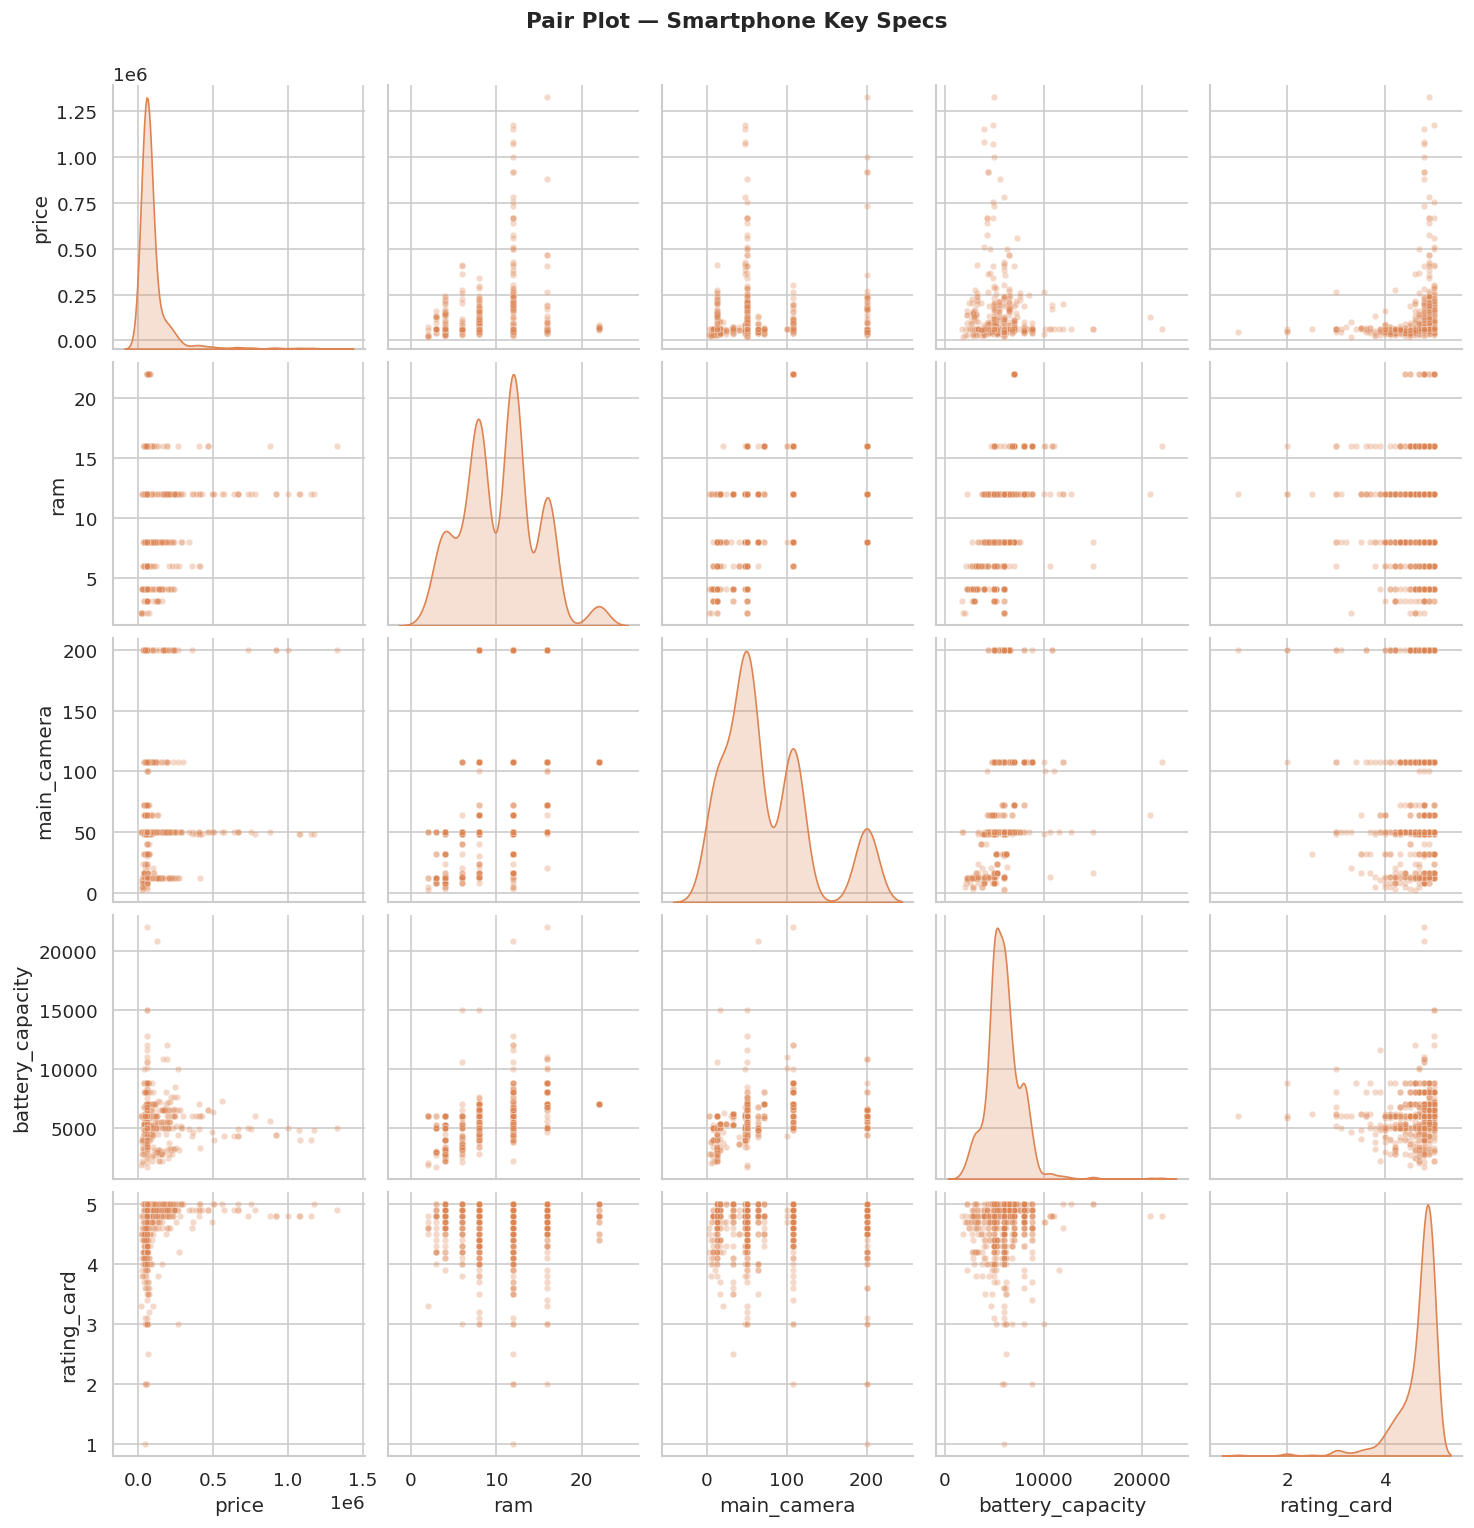

 Caption: Pair plot reveals moderate correlation between RAM and smartphone price. Camera MP and battery are independent specs not linked to rating.


In [267]:
pair_cols = ["price","ram","main_camera","battery_capacity","rating_card"]
df_pair = df2[pair_cols].dropna().sample(min(800, len(df2)), random_state=42)

g = sns.pairplot(df_pair, diag_kind="kde", plot_kws={"alpha":0.3, "color":"#DD8452", "s":15},
                 diag_kws={"color":"#DD8452", "fill":True})
g.fig.suptitle("Pair Plot — Smartphone Key Specs", y=1.02, fontsize=13, fontweight="bold")
plt.savefig("viz9_pairplot_phones.png", bbox_inches="tight")
plt.show()
print(" Caption: Pair plot reveals moderate correlation between RAM and smartphone price. Camera MP and battery are independent specs not linked to rating.")

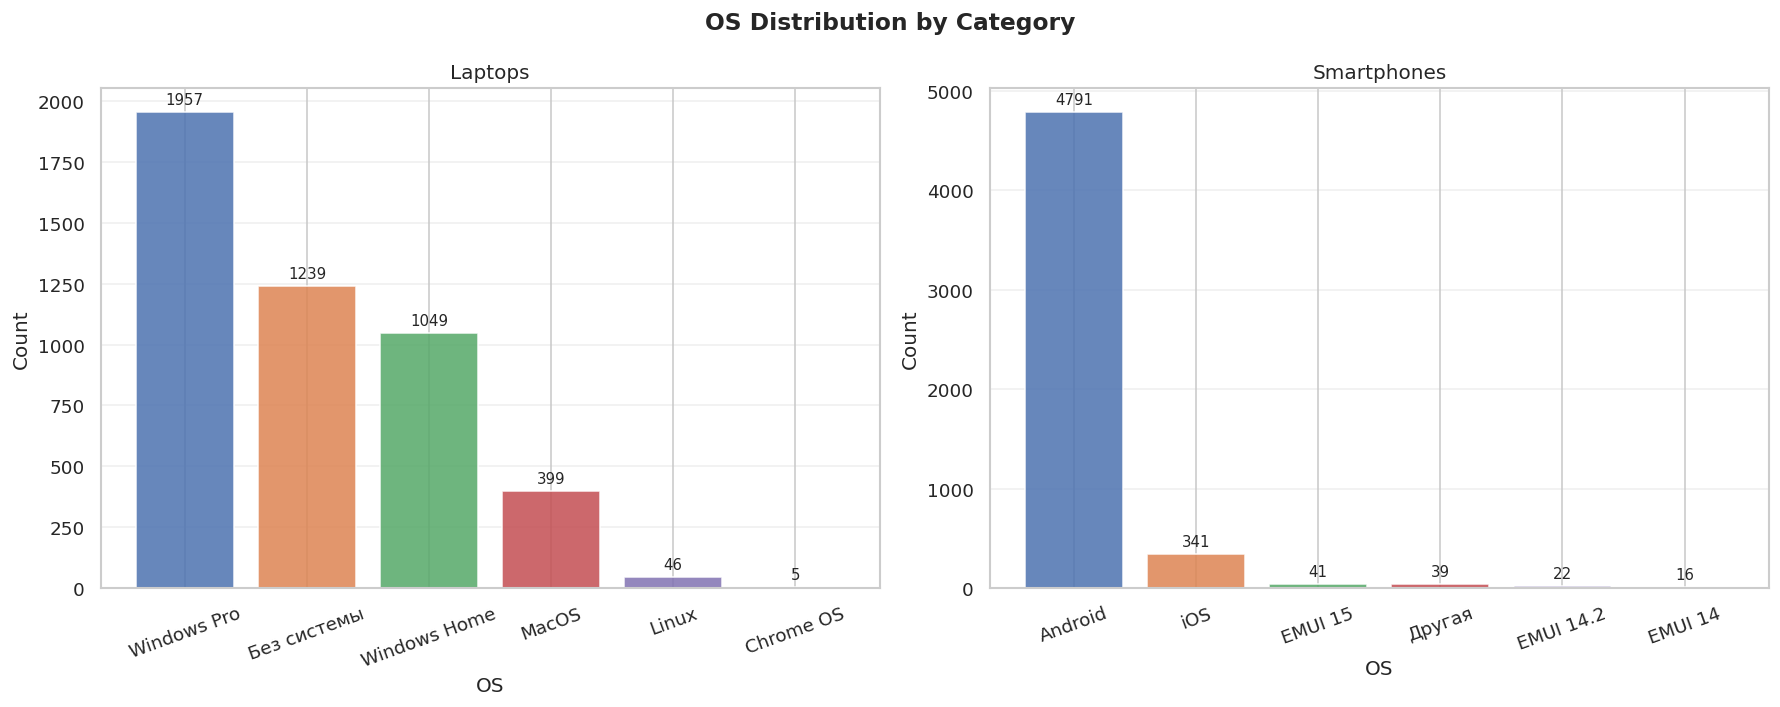

 Caption: Windows Home dominates among laptops, Android dominates among smartphones. MacOS represents a small but expensive niche.


In [268]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle("OS Distribution by Category", fontsize=14, fontweight="bold")

for ax, (df_c, label) in zip(axes, [(df1,"Laptops"),(df2,"Smartphones")]):
    os_counts = (df_c[df_c["os"] != "no_data"]["os"]
                 .value_counts().head(6))
    bars = ax.bar(os_counts.index, os_counts.values,
                  color=CAT_COLORS[:len(os_counts)], edgecolor="white", alpha=0.85)
    ax.bar_label(bars, padding=3, fontsize=9)
    ax.set_title(label, fontsize=12)
    ax.set_xlabel("OS")
    ax.set_ylabel("Count")
    ax.tick_params(axis="x", rotation=20)
    ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig("viz10_bar_os.png", bbox_inches="tight")
plt.show()
print(" Caption: Windows Home dominates among laptops, Android dominates among smartphones. MacOS represents a small but expensive niche.")

In [269]:
df_plot = df_all.dropna(subset=["ram","price","rating_card"]).copy()
df_plot = df_plot[df_plot["price"] < df_plot["price"].quantile(0.97)]
df_plot["rating_card"] = df_plot["rating_card"].clip(1, 5)

fig = px.scatter(
    df_plot, x="ram", y="price",
    color="category",
    size="rating_card",
    hover_data=["processor_brand","reviews_card"],
    color_discrete_map=PALETTE,
    opacity=0.55,
    title="RAM vs Price by Category (size = rating)",
    labels={"ram":"RAM (GB)", "price":"Price (₸)", "category":"Category"},
    template="plotly_white"
)
fig.update_layout(title_font_size=15, legend_title_text="Category")
fig.show()
print(" Caption: Interactive scatter plot for exploring price vs RAM. Hover over a point to see processor brand and review count.")

 Caption: Interactive scatter plot for exploring price vs RAM. Hover over a point to see processor brand and review count.


In [270]:
df_disc = df_all[df_all["discount_pct"].between(1, 90)].copy()

fig = px.box(
    df_disc, x="category", y="discount_pct",
    color="category",
    color_discrete_map=PALETTE,
    points="outliers",
    notched=True,
    title="Discount % Distribution by Category",
    labels={"category":"Category", "discount_pct":"Discount (%)"},
    template="plotly_white"
)
fig.update_layout(title_font_size=15, showlegend=False)
fig.show()
print(" Caption: Median discount for smartphones is higher than for laptops. Many outliers with 70-90% discounts suggest artificial inflation of old_price by sellers.")

 Caption: Median discount for smartphones is higher than for laptops. Many outliers with 70-90% discounts suggest artificial inflation of old_price by sellers.


In [271]:
top10_laptops = (df1.dropna(subset=["name_card","reviews_card"])
                 .nlargest(10, "reviews_card")
                 [["name_card","reviews_card","price","rating_card","processor_brand"]])
top10_laptops["short_name"] = top10_laptops["name_card"].str[:40] + "..."

fig = px.bar(
    top10_laptops.sort_values("reviews_card"),
    x="reviews_card", y="short_name",
    orientation="h",
    color="price",
    color_continuous_scale="Blues",
    hover_data=["rating_card","processor_brand"],
    title="Top-10 Most Reviewed Laptops",
    labels={"reviews_card":"Reviews Count", "short_name":"Product", "price":"Price (₸)"},
    template="plotly_white"
)
fig.update_layout(title_font_size=15, yaxis_title="")
fig.show()
print(" Caption: Top reviewed products are mostly budget and mid-range laptops (lighter = cheaper). Popularity does not equal high price.")

 Caption: Top reviewed products are mostly budget and mid-range laptops (lighter = cheaper). Popularity does not equal high price.


In [273]:
import plotly.express as px
import pandas as pd

# Smartphones — filter no_data
df_sun = df2[
    (df2["processor_brand"] != "no_data") &
    (df2["os"] != "no_data")
].copy()

# Top-5 processor brands
top_brands = df2["processor_brand"].value_counts().head(5).index
df_sun = df_sun[df_sun["processor_brand"].isin(top_brands)]

# Group
grp = (df_sun.groupby(["processor_brand", "os"])
       .agg(count=("price", "count"), median_price=("price", "median"))
       .reset_index())

fig = px.sunburst(
    grp,
    path=["processor_brand", "os"],
    values="count",
    color="median_price",
    color_continuous_scale="RdYlGn",
    title="Smartphones: Processor Brand -> OS -> Market Share",
    hover_data={"median_price": ":,.0f"},
    color_continuous_midpoint=grp["median_price"].median(),
)

fig.update_layout(
    title=dict(font=dict(size=17, family="Arial Black"), x=0.5),
    coloraxis_colorbar=dict(title="Median Price (₸)"),
    width=700, height=650,
    template="plotly_white",
    annotations=[dict(
        text=" Qualcomm+Android dominates the market. Apple/iOS is a small but the most expensive segment (dark green).",
        xref="paper", yref="paper",
        x=0.5, y=-0.08, showarrow=False,
        font=dict(size=11, color="gray"), align="center"
    )]
)

fig.show()
